<div style="border:solid green 2px; padding: 20px">
    
<b>Арсений, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# Постановка задачи и требования

**Цель:** 
- построить модель прогнозирования статуса клиента: лояльный или может уйти

**Формализация:**
- задача бинарной классификации для прогнозирования вероятности оттока каждого клиента в следующем месяце

**Требования к работе модели**
- важно минимизировать количество ложных срабатываний модели, то есть ошибок, из-за которых лояльный клиент, который не планирует уходить, ошибочно определяется как «уходящий».

**Ключевые метрики:**
- Recall, или полнота, отвечает на вопрос: «Какую долю всех уходящих клиентов удаётся предсказать?» Высокий Recall минимизирует шанс «проглядеть» клиентов, которые готовы уйти.
- Precision, или точность, отвечает на вопрос: «Какая часть клиентов, распознанных как уходящие, действительно уйдёт?» Высокий Precision минимизирует затраты на удержание лояльных клиентов, которые уходить не собираются.
- F1-мера - компромисс между  Recall и Precision.
- В настоящей задаче классы несбалансированы. Более адекватной и информативной метрикой для оценки качества модели может послужить Precision-Recall AUC (PR AUC).


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, вводная часть имеется

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from phik import phik_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc, precision_recall_fscore_support
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import FunctionTransformer
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyClassifier


In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [4]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [5]:
# фиксируем seed для воспроизводимости
RANDOM_STATE = 42

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

загрузил данные корректно и зафиксировал RANDOM_STATE

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
В проекте нет фиксации версий пакетов в requirements.txt, хотя это было отдельным требованием задания

<div class="alert alert-info"> <b>Комментарии студента:</b> Выгрузил в проект на github, теперь версии библиотек явно прописаны в pyproject.toml. Надеюсь, использование uv не критично.</div>

## Этап 2. Первичный анализ данных


### Описание пользователей и их поведения

In [6]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


**Дубли**

In [7]:
df['user_id'].nunique()  # все id уникальны

10450

In [8]:
df.duplicated().sum() # явных дублей нет

np.int64(0)

**Пропуски**

In [9]:
# явные пропуски
df.isna().sum() / len(df) * 100

user_id                     0.000000
days_since_last_order       9.043062
order_frequency_month       5.741627
order_frequency_week        3.712919
avg_order_value             5.578947
median_order_value          7.952153
total_spent_last_month      2.813397
total_spent_last_week       9.033493
discount_usage_rate         3.799043
last_coffee_type            2.468900
preferred_roast             1.110048
milk_preference             6.392344
seasonal_menu_tried         9.464115
coffee_bean_origin          6.526316
last_drink_size             4.822967
subscription_status         8.976077
app_opens_per_week          8.574163
notifications_enabled       5.138756
review_rating_last_10       6.631579
review_rating_last_1        8.200957
app_crashes_last_month      6.899522
seasons                     6.497608
days_since_last_promo       6.995215
phone_type                  3.215311
coffee_preference_change    5.837321
geo_location                1.052632
churn                       0.000000
d

Анализ:
- пропуски есть во всех колонках, кроме user_id и churn
- количество пропусков в колонках существенное: от 1 до 10% 

In [10]:
# неявные пропуски для категориальных данных
df['user_id'].nunique() # неявных пропусков нет (все id уникальные)

10450

In [11]:
np.sort(df['geo_location'].unique().dropna())  # неявных пропусков нет

array(['geo_1', 'geo_10', 'geo_100', 'geo_11', 'geo_12', 'geo_13',
       'geo_14', 'geo_15', 'geo_16', 'geo_17', 'geo_18', 'geo_19',
       'geo_2', 'geo_20', 'geo_21', 'geo_22', 'geo_23', 'geo_24',
       'geo_25', 'geo_26', 'geo_27', 'geo_28', 'geo_29', 'geo_3',
       'geo_30', 'geo_31', 'geo_32', 'geo_33', 'geo_34', 'geo_35',
       'geo_36', 'geo_37', 'geo_38', 'geo_39', 'geo_4', 'geo_40',
       'geo_41', 'geo_42', 'geo_43', 'geo_44', 'geo_45', 'geo_46',
       'geo_47', 'geo_48', 'geo_49', 'geo_5', 'geo_50', 'geo_51',
       'geo_52', 'geo_53', 'geo_54', 'geo_55', 'geo_56', 'geo_57',
       'geo_58', 'geo_59', 'geo_6', 'geo_60', 'geo_61', 'geo_62',
       'geo_63', 'geo_64', 'geo_65', 'geo_66', 'geo_67', 'geo_68',
       'geo_69', 'geo_7', 'geo_70', 'geo_71', 'geo_72', 'geo_73',
       'geo_74', 'geo_75', 'geo_76', 'geo_77', 'geo_78', 'geo_79',
       'geo_8', 'geo_80', 'geo_81', 'geo_82', 'geo_83', 'geo_84',
       'geo_85', 'geo_86', 'geo_87', 'geo_88', 'geo_89', 'geo_9',
   

In [12]:
cat_cols = [
    'last_coffee_type', 'preferred_roast', 
    'milk_preference', 'coffee_bean_origin',
    'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 
    ]
for name in cat_cols:
    print(name, df[name].unique())

last_coffee_type <StringArray>
['blend', 'arabica', 'robusta', nan]
Length: 4, dtype: str
preferred_roast <StringArray>
['light', 'medium', 'dark', nan]
Length: 4, dtype: str
milk_preference <StringArray>
['almond', 'whole', 'oat', 'skim', 'soy', nan, 'none']
Length: 7, dtype: str
coffee_bean_origin <StringArray>
['vietnam', 'guatemala', 'brazil', 'colombia', 'kenya', nan, 'ethiopia']
Length: 7, dtype: str
last_drink_size <StringArray>
['large', 'medium', 'small', nan]
Length: 4, dtype: str
subscription_status <StringArray>
['pro', 'none', 'premium', 'basic', nan]
Length: 5, dtype: str
seasons <StringArray>
['summer', 'autumn', 'spring', 'winter', nan]
Length: 5, dtype: str
phone_type <StringArray>
['android', 'ios', 'web', nan]
Length: 4, dtype: str


Анализ:
- неявные пропуски присутствуют среди признаков: 
    - milk_preference - 'none'
    - subscription_status - 'none'

- для корректной обработки в дальнейшем стоит их заменить на nan, чтобы сделать явными

**Типы данных**

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

Анализ:
- типы данных соответствуют описанию. 
- можно провести оптимизацию по занимаемой памяти (понижение размерности)

**Статистики количественных данных**

In [14]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Анализ:
- имеются ошибки в данных (отрицательные значения): order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_week, review_rating_last_1 


**Распределение целевого класса внутри признаков**

- рассмотрим плотность распределения признаков по целевому классу

In [15]:
def plot_target_class_dist(feature_names_list: list[str], df: pd.DataFrame=df, median_show: bool = True, fig_sz: tuple[int, int] = (12, 5), density: bool = True):
    # Определяем размер сетки (2 столбца, строки подбираем автоматически)
    n_features = len(feature_names_list)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_sz[0], fig_sz[1] * n_rows))
    axes = axes.flatten()  # упрощаем индексацию

    idx_1 = np.where(df['churn'] == 1)
    idx_0 = np.where(df['churn'] == 0)
    for i, feature in enumerate(feature_names_list):
        ax = axes[i]
        data = df[feature]

        data_1 = data.iloc[idx_1]
        data_0 = data.iloc[idx_0]

        if median_show:
            median_1 = data_1.median()
            median_0 = data_0.median()
            ax.axvline(median_1, color='C0', linestyle='--', linewidth=2,
                   label=f'churn = 1 median: {median_1:.2f}')
            ax.axvline(median_0, color='C1', linestyle='--', linewidth=2,
                   label=f'churn = 0 median: {median_0:.2f}')

        ax.hist(data_1, bins=30, density=density, alpha=0.5, label='churn = 1')
        ax.hist(data_0, bins=30, density=density, alpha=0.5, label='churn = 0')

        ax.set_title(f'Распределение признака {feature} по классам churn')
        ax.set_xlabel(feature)
        ax.set_ylabel('плотность' if density else 'частота')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    # Если есть лишние оси (когда признаков меньше, чем ячеек), скрываем их
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



In [16]:
# количественные дискретные признаки
num_discrete_features = [
    'seasonal_menu_tried', 'notifications_enabled', 'app_crashes_last_month', 'days_since_last_promo',
    'coffee_preference_change'
]

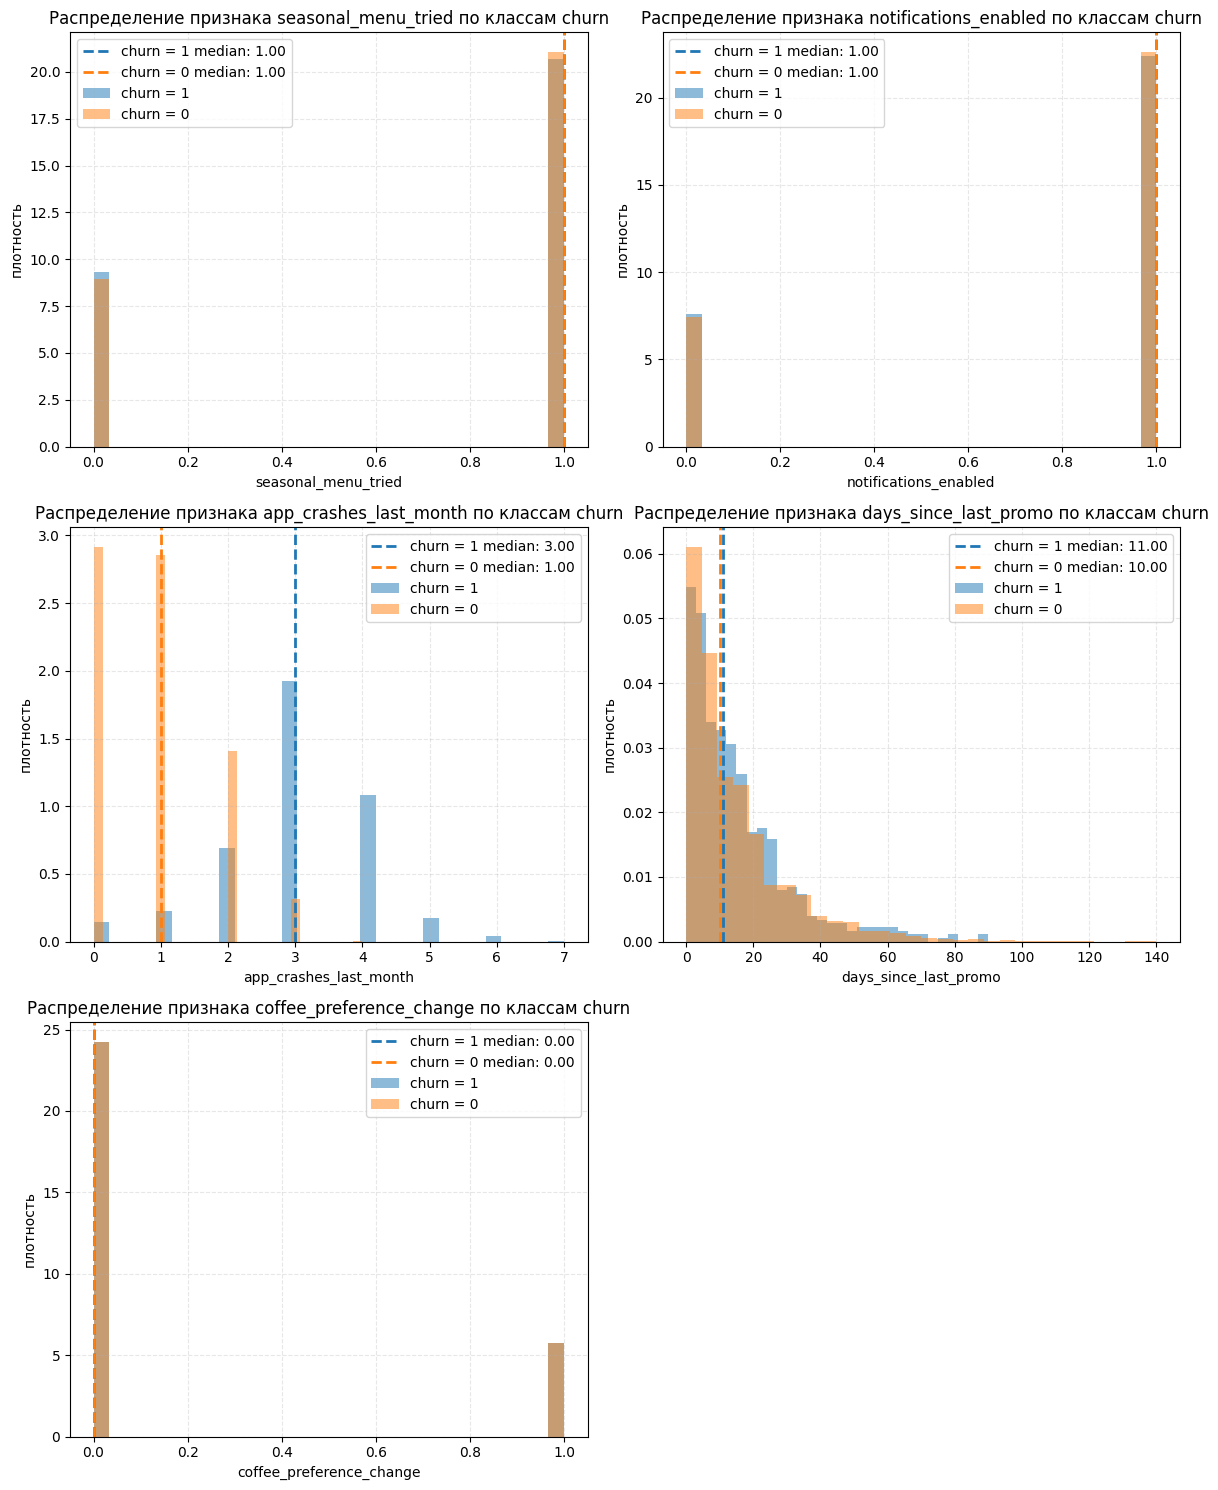

In [17]:
plot_target_class_dist(
    feature_names_list=num_discrete_features, df=df
)

Анализ:
- внутри признака app_crashes_last_month можно выделить отличия в распределениях по классу churn: 
    - при churn = 1: распределение более симметричное, смещенное вправо, медианное значение 3 (клиенты становятся нелояльными при большом количестве отазов приложения)
    - при churn = 0: распределение смещено влево, медианное значнение 1

Рекомендация:
- чтобы лучше отделить два класса внутри app_crashes_last_month можно рассмотреть преобразования признака: 
    - биннинг: 0-2 отказа, 3 и более отказов
    - возведедие в степень (pow2)


In [18]:
# количественные непрерывные признаки
num_continues_features = [
    'days_since_last_order', 'order_frequency_month', 
    'order_frequency_week', 'avg_order_value',
    'median_order_value', 'total_spent_last_month', 
    'total_spent_last_week', 'discount_usage_rate',
    'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 
]

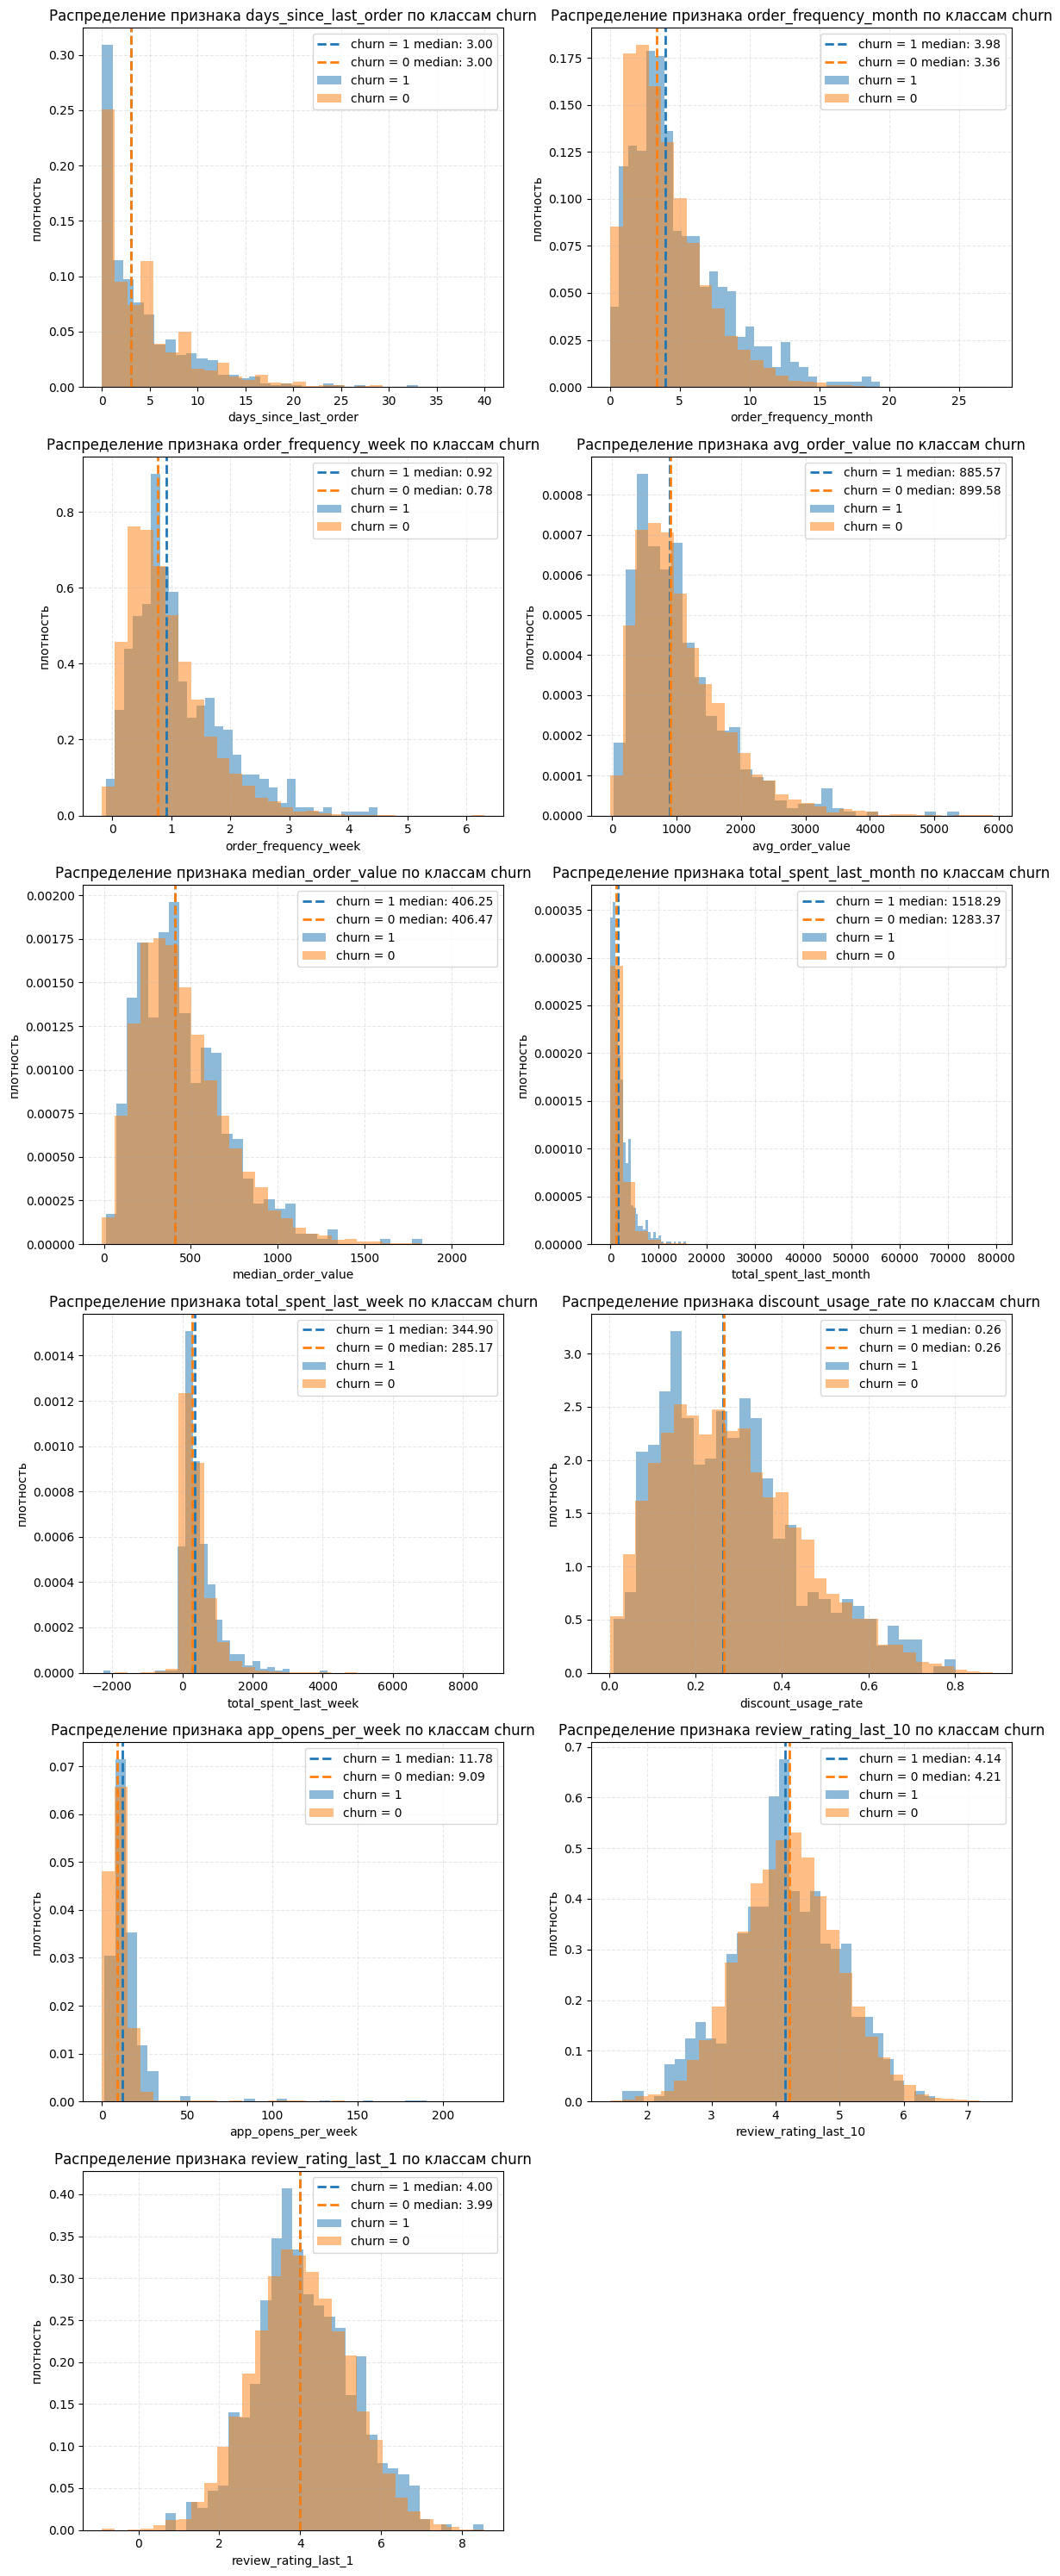

In [19]:
plot_target_class_dist(
    feature_names_list=num_continues_features, df=df
)

Анализ:
- визуально отличий внутри распределений нет, медианы отличаются мало

Рекомендация:
- к скошенным влево распределениям можно применить преобразования логарифма, чтобы добиться более симметричной картины

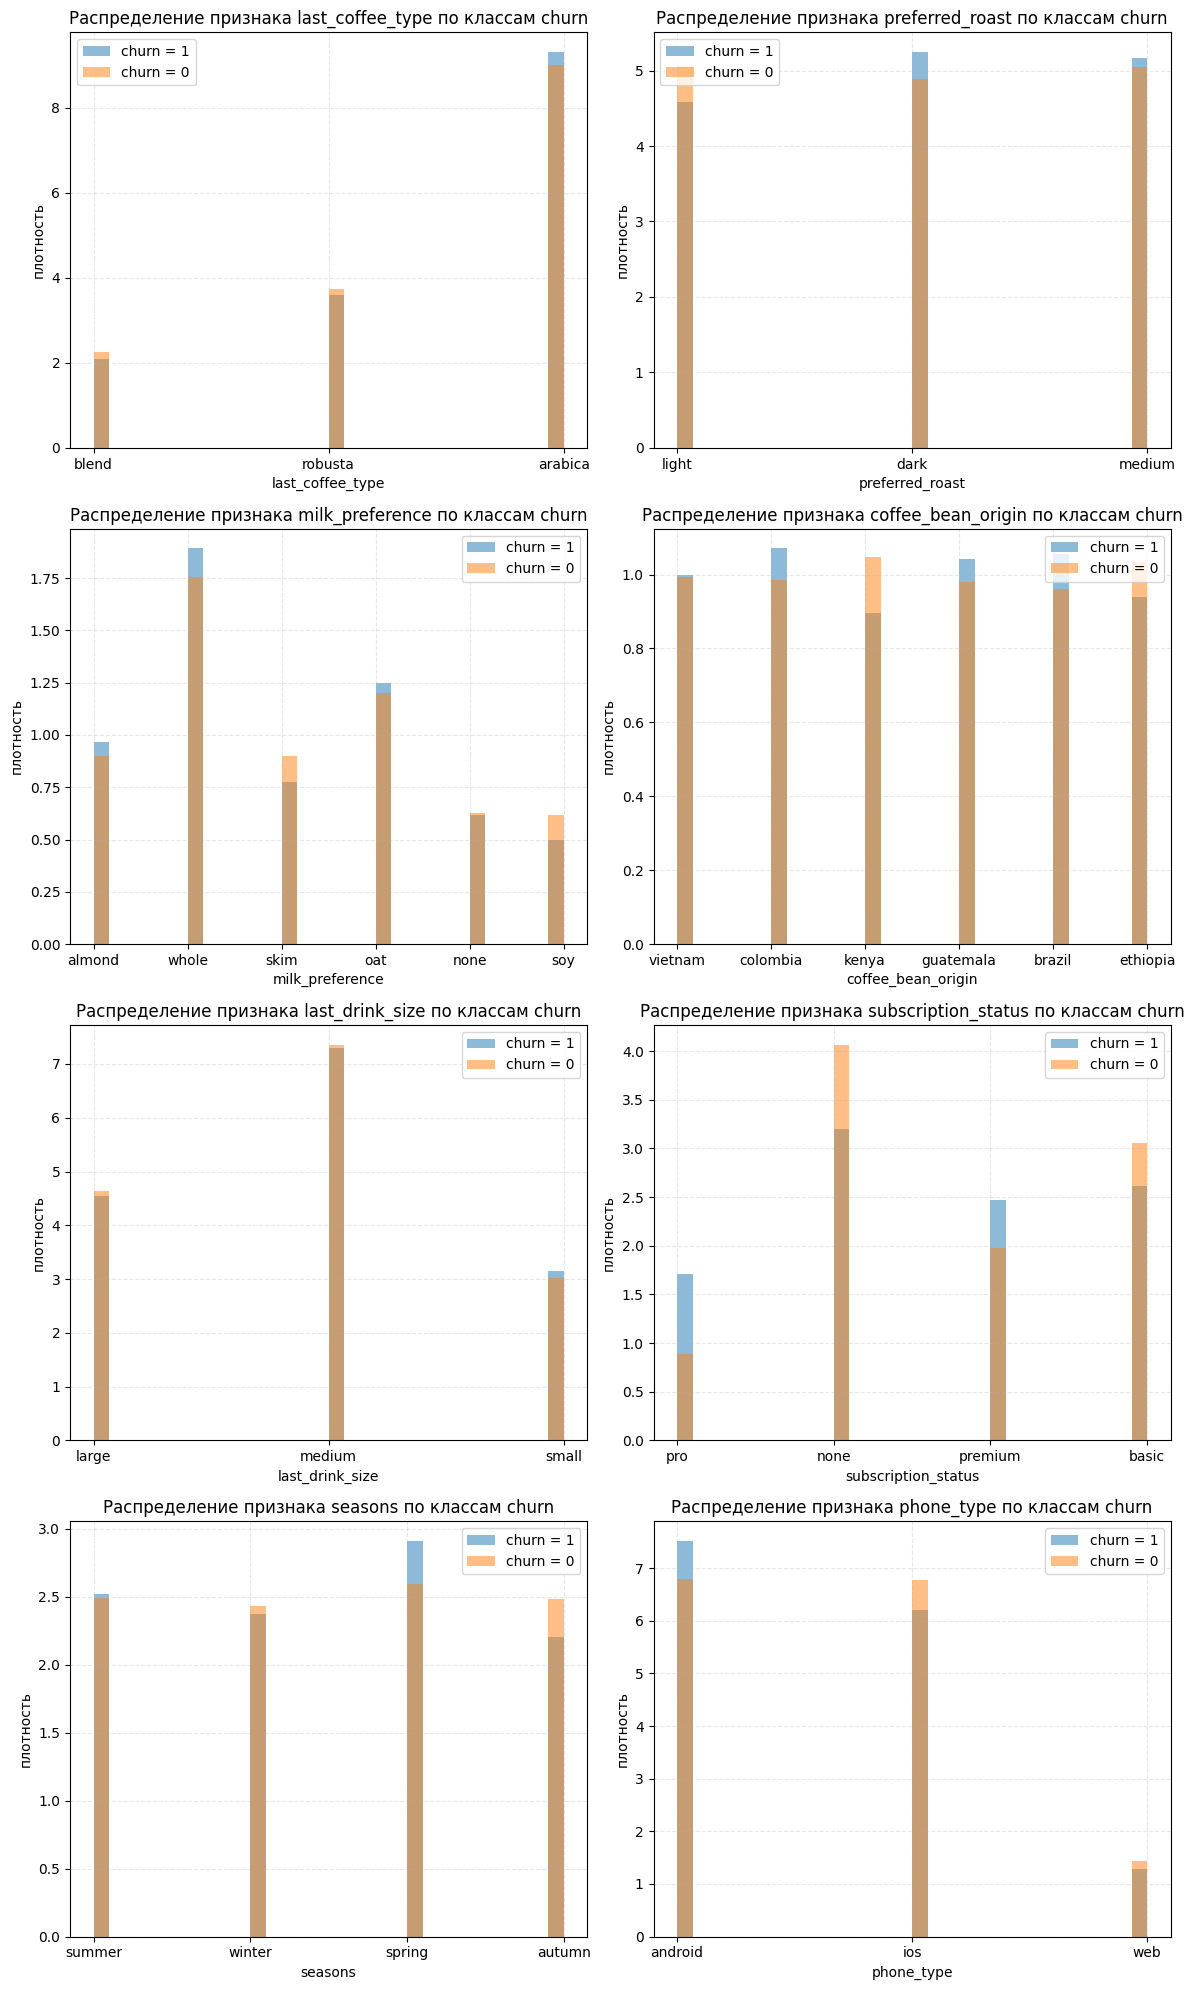

In [20]:
# категориальные признаки:
plot_target_class_dist(
    feature_names_list=cat_cols, df=df[cat_cols + ['churn']].dropna(), median_show=False
)


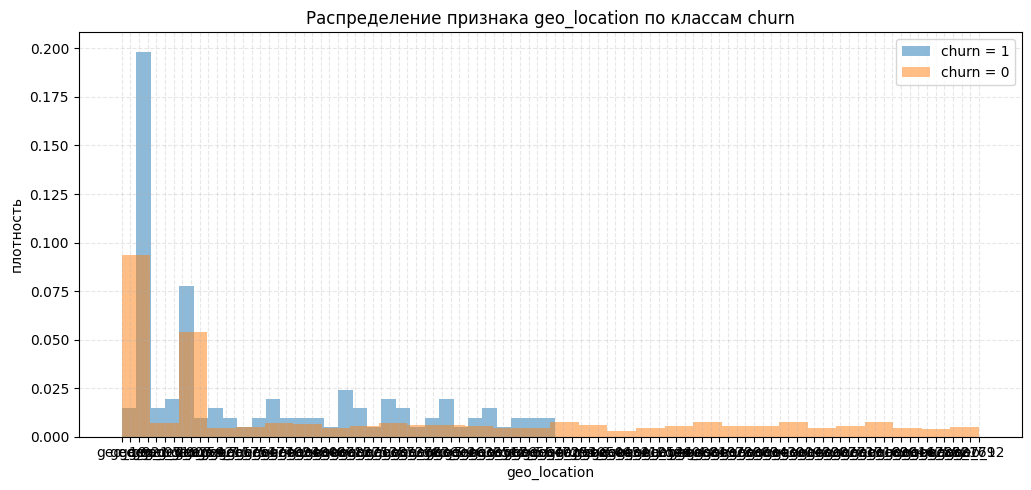

In [21]:

plot_target_class_dist(
    feature_names_list=['geo_location'], df=df.dropna(), median_show=False, fig_sz=(20, 5)
)

Анализ:
- нелояльные клиенты имеются только в части регионов


### Итог:

--- 
#### 1. Общая информация
Данные содержат иформацию о 10450 уникальных пользователях. 26 признаков, характеризующих их активность:

0) Идентификация:
    - user_id

1) Характеристики времени: 
    - days_since_last_order, 
    - order_frequency_month, 
    - order_frequency_week
    - days_since_last_promo
    - seasons


2) Потреченные деньги: 
    - avg_order_value 
    - median_order_value	
    - total_spent_last_month	
    - total_spent_last_week


3) Специальные условия заказов:
    - discount_usage_rate
    - seasonal_menu_tried
    - subscription_status
    
    
4) Использование мобильного приложения:
    - app_opens_per_week
    - notifications_enabled
    - app_crashes_last_month


5) Персональные предпочтения
    - coffee_preference_change
    - last_coffee_type
    - preferred_roast
    - last_drink_size


6) Удовлетворенность сервисом:
    - review_rating_last_10	
    - review_rating_last_1
    
    
7) География:
    - geo_location
    - coffee_bean_origin

Бинарный признак для предсказаия (лояльность сервису):
- churn


#### 2. Анализ пропусков, дубликатов, выбросов

Наблюдения:

1. Явные пропуски имеются во всех столбцах, кроме user_id и churn. 
2. Есть неявные пропуски в виде 'none' в столбцах milk_preference, subscription_status
3. В данных нет явных дубликатов, все пользователи уникальные
4. Формат данных соответсвует описанию

Рекомендации:

1. Провести обработку неявных пропусков для milk_preference, subscription_status, преобразовать в явные для корретной работы в дальнейшем
2. Провести понижение размерности данных исходя из используемого ими диапазона значений. Это приведет к экономии памяти.


#### Анализ распределений 

Наблюдения:
1. Внутри признака app_crashes_last_month можно выделить отличия в распределениях по классу churn. Клиенты становятся нелояльными при большом количестве отазов приложения.
2. Нелояльные клиенты есть только в части регионов.

Рекомендации:
1. чтобы лучше отделить два класса внутри app_crashes_last_month можно рассмотреть преобразования признака: 
    - биннинг: 0-2 отказа, 3 и более отказов
    - возведедие в степень (pow2)
2. Непрерывные количесвтенные данные имеют скошенные влево распределения. Можно применить преобразования логарифма, чтобы добиться более симметричной картины
3. Необходимо отдельно исследовать приведенные к числовым значениям признак региона. Возможно, это поможет более явно отделить нелояльных клиентов по локации 


---

In [22]:
def replace_implicit_none_with_nan(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """Замена неявных пропусков ('none') на явные NaN"""
    df_upd = df.copy()
    mask = df_upd[col_name] == 'none'
    df_upd.loc[mask, col_name] = np.nan
    return df_upd

In [23]:
# замена неявных пропусков в данных milk_preference, subscription_status 

df = replace_implicit_none_with_nan(df=df, col_name='milk_preference')
df = replace_implicit_none_with_nan(df=df, col_name='subscription_status')

In [24]:
df['milk_preference'].unique()

<StringArray>
['almond', 'whole', 'oat', 'skim', 'soy', nan]
Length: 6, dtype: str

In [25]:
df['subscription_status'].unique()

<StringArray>
['pro', nan, 'premium', 'basic']
Length: 4, dtype: str

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

В этом разделе почти нет полноценного EDA. По сути показаны info(), head() и список колонок, но нет нормального анализа распределений, пропусков и поведения пользователей по ключевым признакам

<div class="alert alert-info"> <b>Комментарии студента:</b> Добавил более детальную аналитику.</div>

### Опиcание целевой переменной. 


In [26]:
df['churn'].describe()

count    10450.000000
mean         0.060191
std          0.237852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64

In [27]:
df['churn'].unique()

array([1, 0])

- Целевая переменная -- бинарный признак. Пропусков нет

Процентное соотношение значений:


churn
0    93.980861
1     6.019139
Name: count, dtype: float64

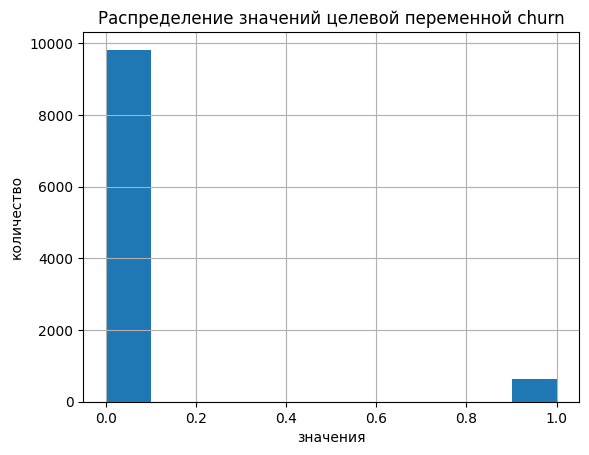

In [28]:
# анализ распределения
targer_var = 'churn'
df.hist(column=targer_var)
plt.title(f'Распределение значений целевой переменной {targer_var}')
plt.ylabel('количество')
plt.xlabel('значения')

value_percentage = df['churn'].value_counts() / len(df['churn']) * 100
print('Процентное соотношение значений:')
value_percentage

- присутствует дисбаланс классов в целевой переменной: 
    - 0: 94%
    - 1: 6%

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
Дисбаланс зафиксирован

### Выявление несодержательных признаков и фильрация.


In [29]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


**Анализ:**
- user_id - уникальный id пользователя. Признак для анализа не несет пользы. Его стоит удалить
- остальные признаки требуют дополнительного исследования для определения их влияния на модель прогноза целевого класса

In [30]:
# очистка данных от несодержательных признаков
df.drop(columns=['user_id'], inplace=True)

In [31]:
df.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Удаление coffee_bean_origin и seasons здесь не обосновано достаточно хорошо. Для ML-проекта признак не обязан напрямую "описывать пользователя", он должен помогать предсказывать целевую переменную. Такие признаки нельзя удалять просто потому, что они кажутся второстепенными

<div class="alert alert-info"> <b>Комментарии студента:</b> Исправил. На данном этапе эти признаки не удаляю. </div>

### Анализ пропусков.

In [32]:
df.isna().sum() / len(df) * 100

days_since_last_order        9.043062
order_frequency_month        5.741627
order_frequency_week         3.712919
avg_order_value              5.578947
median_order_value           7.952153
total_spent_last_month       2.813397
total_spent_last_week        9.033493
discount_usage_rate          3.799043
last_coffee_type             2.468900
preferred_roast              1.110048
milk_preference             16.105263
seasonal_menu_tried          9.464115
coffee_bean_origin           6.526316
last_drink_size              4.822967
subscription_status         45.368421
app_opens_per_week           8.574163
notifications_enabled        5.138756
review_rating_last_10        6.631579
review_rating_last_1         8.200957
app_crashes_last_month       6.899522
seasons                      6.497608
days_since_last_promo        6.995215
phone_type                   3.215311
coffee_preference_change     5.837321
geo_location                 1.052632
churn                        0.000000
dtype: float

Анализ:
- пропусков нет в целевой переменной
- особенно много пропусков в subscription_status - 45%, milk_preference - 16%
- среди остальных признаков количество пропусков варьрируется от 1% до 10%.
- необходимо заменить пропуски на характерные значения, чтобы не потерять полезную информацию.

Рекомендация по заполнению пропусков:
- для числовых признаков пропуски заменяем на статистику: медиану. Это позволит избежать смещения распределения при наличии выбросов
- для категориальных признаков: заменяем на моду (самое часто встечающееся значение)

### Анализ категориальных признаков.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_month     9850 non-null   float64
 2   order_frequency_week      10062 non-null  float64
 3   avg_order_value           9867 non-null   float64
 4   median_order_value        9619 non-null   float64
 5   total_spent_last_month    10156 non-null  float64
 6   total_spent_last_week     9506 non-null   float64
 7   discount_usage_rate       10053 non-null  float64
 8   last_coffee_type          10192 non-null  str    
 9   preferred_roast           10334 non-null  str    
 10  milk_preference           8767 non-null   str    
 11  seasonal_menu_tried       9461 non-null   float64
 12  coffee_bean_origin        9768 non-null   str    
 13  last_drink_size           9946 non-null   str    
 14  subscription_stat

В данных есть категориальные признаки. 
Их стоит закодировать, поскольку модель логистической регрессии работает только с числовыми параметрами

In [34]:
cat_features = [
    'last_coffee_type', 'preferred_roast', 
    'milk_preference', 'last_drink_size', 
    'subscription_status',
    'phone_type',
    'geo_location'
]

Рассмотрим количество уникальных значений для каждого категориального признака, чтобы определиться с кодировкой:

In [35]:
cat_feat_nunique = {name: df[name].nunique() for name in cat_features}

cat_feat_nunique

{'last_coffee_type': 3,
 'preferred_roast': 3,
 'milk_preference': 5,
 'last_drink_size': 3,
 'subscription_status': 3,
 'phone_type': 3,
 'geo_location': 100}

Стратегия кодирования категориальных признаков:
- уникальных значений для признака 'geo_location' 100шт и это достаточно много. Используем TargetEncoding, чтобы количество признаков не выросло слишком сильно. 
- среди других признаков уникальных значений мало (< 10). Используем One-Hot Encoding

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Здесь можно было коротко объяснить, почему именно TargetEncoding подходит для признака с 100 категориями лучше, чем OHE

<div class="alert alert-info"> <b>Комментарии студента:</b> Добавил пояснение, почему TargetEncoding применяю к geo_location.</div>

### Анализ выбросов


In [36]:
def plot_hists(
    feature_names_list: list[str],
    df: pd.DataFrame,
    percentile: float | None = None,   
    bins: int = 30
):
    n_features = len(feature_names_list)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols if n_features > 0 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = np.array(axes).flatten()

    for i, feature in enumerate(feature_names_list):
        ax = axes[i]
        data = df[feature].dropna()

        # Гистограмма
        ax.hist(data, bins=bins, edgecolor='black', alpha=0.7)

        # Вертикальная линия перцентиля по значениям признака
        if percentile is not None:
            if not (0 <= percentile <= 100):
                raise ValueError("percentile должен быть в диапазоне [0, 100]")
            p_val = np.percentile(data, percentile)
            ax.axvline(
                x=p_val, color='red', linestyle='--', linewidth=2,
                label=f'{percentile}-й перцентиль: {p_val:.2f}'
            )
            ax.legend()

        ax.set_title(f'Распределение для {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Частота')
        ax.grid(True, linestyle='--', alpha=0.3)

    # Скрываем лишние оси
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



In [37]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Анализ:
- order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_month, review_rating_last_1 - есть ошибки в виде отрицательных значений. Заменим на пропуски. После разделения на train/test можно будет заменить пропуски на медианы, чтобы избежать утечки данных
- для обработки выбросов в непрерырных признаках воспользуемся z-score. Выбросы фильтруем по 3-сигма порогу и заменяем на медиану (После разделения на train/test)

**Обработка отрицательных значений**

In [38]:
def replace_negative_error_with_nan(data: pd.Series):
    """Замена ошибок в виде отрицательных значений на пропуски nan"""
    data = data.copy()  #  работа с копией
    negative_val_error_mask = data < 0
    data[negative_val_error_mask] = np.nan
    return data

In [39]:
columns_with_negative_errors = [
    'order_frequency_week', 'avg_order_value', 
    'median_order_value', 'total_spent_last_month', 
    'review_rating_last_1', 'total_spent_last_week'
]

In [40]:
# замена ошибок на пропуски
for name in columns_with_negative_errors:
    df[name] = replace_negative_error_with_nan(df[name])

**Замена выбросов по z-оценке для непрерывных признаков**
- реализация функции обработки выбросов
- применение после разделения на train/test для избежания утечки данных

In [41]:
def replace_zscore_outliers_with_median(data: pd.Series, sigmas_threshold: float = 3):
    """Замена выбросов по z-оценке на медианы"""
    data = data.copy()
    z_score_outliers_mask = np.abs(zscore(data)) > sigmas_threshold
    median = data[~z_score_outliers_mask].median()
    data[z_score_outliers_mask] = median
    return data

In [42]:
# количественные непрерывные признаки
num_continues_features = [
    'days_since_last_order', 'order_frequency_month', 
    'order_frequency_week', 'avg_order_value',
    'median_order_value', 'total_spent_last_month', 
    'total_spent_last_week', 'discount_usage_rate',
    'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 
]

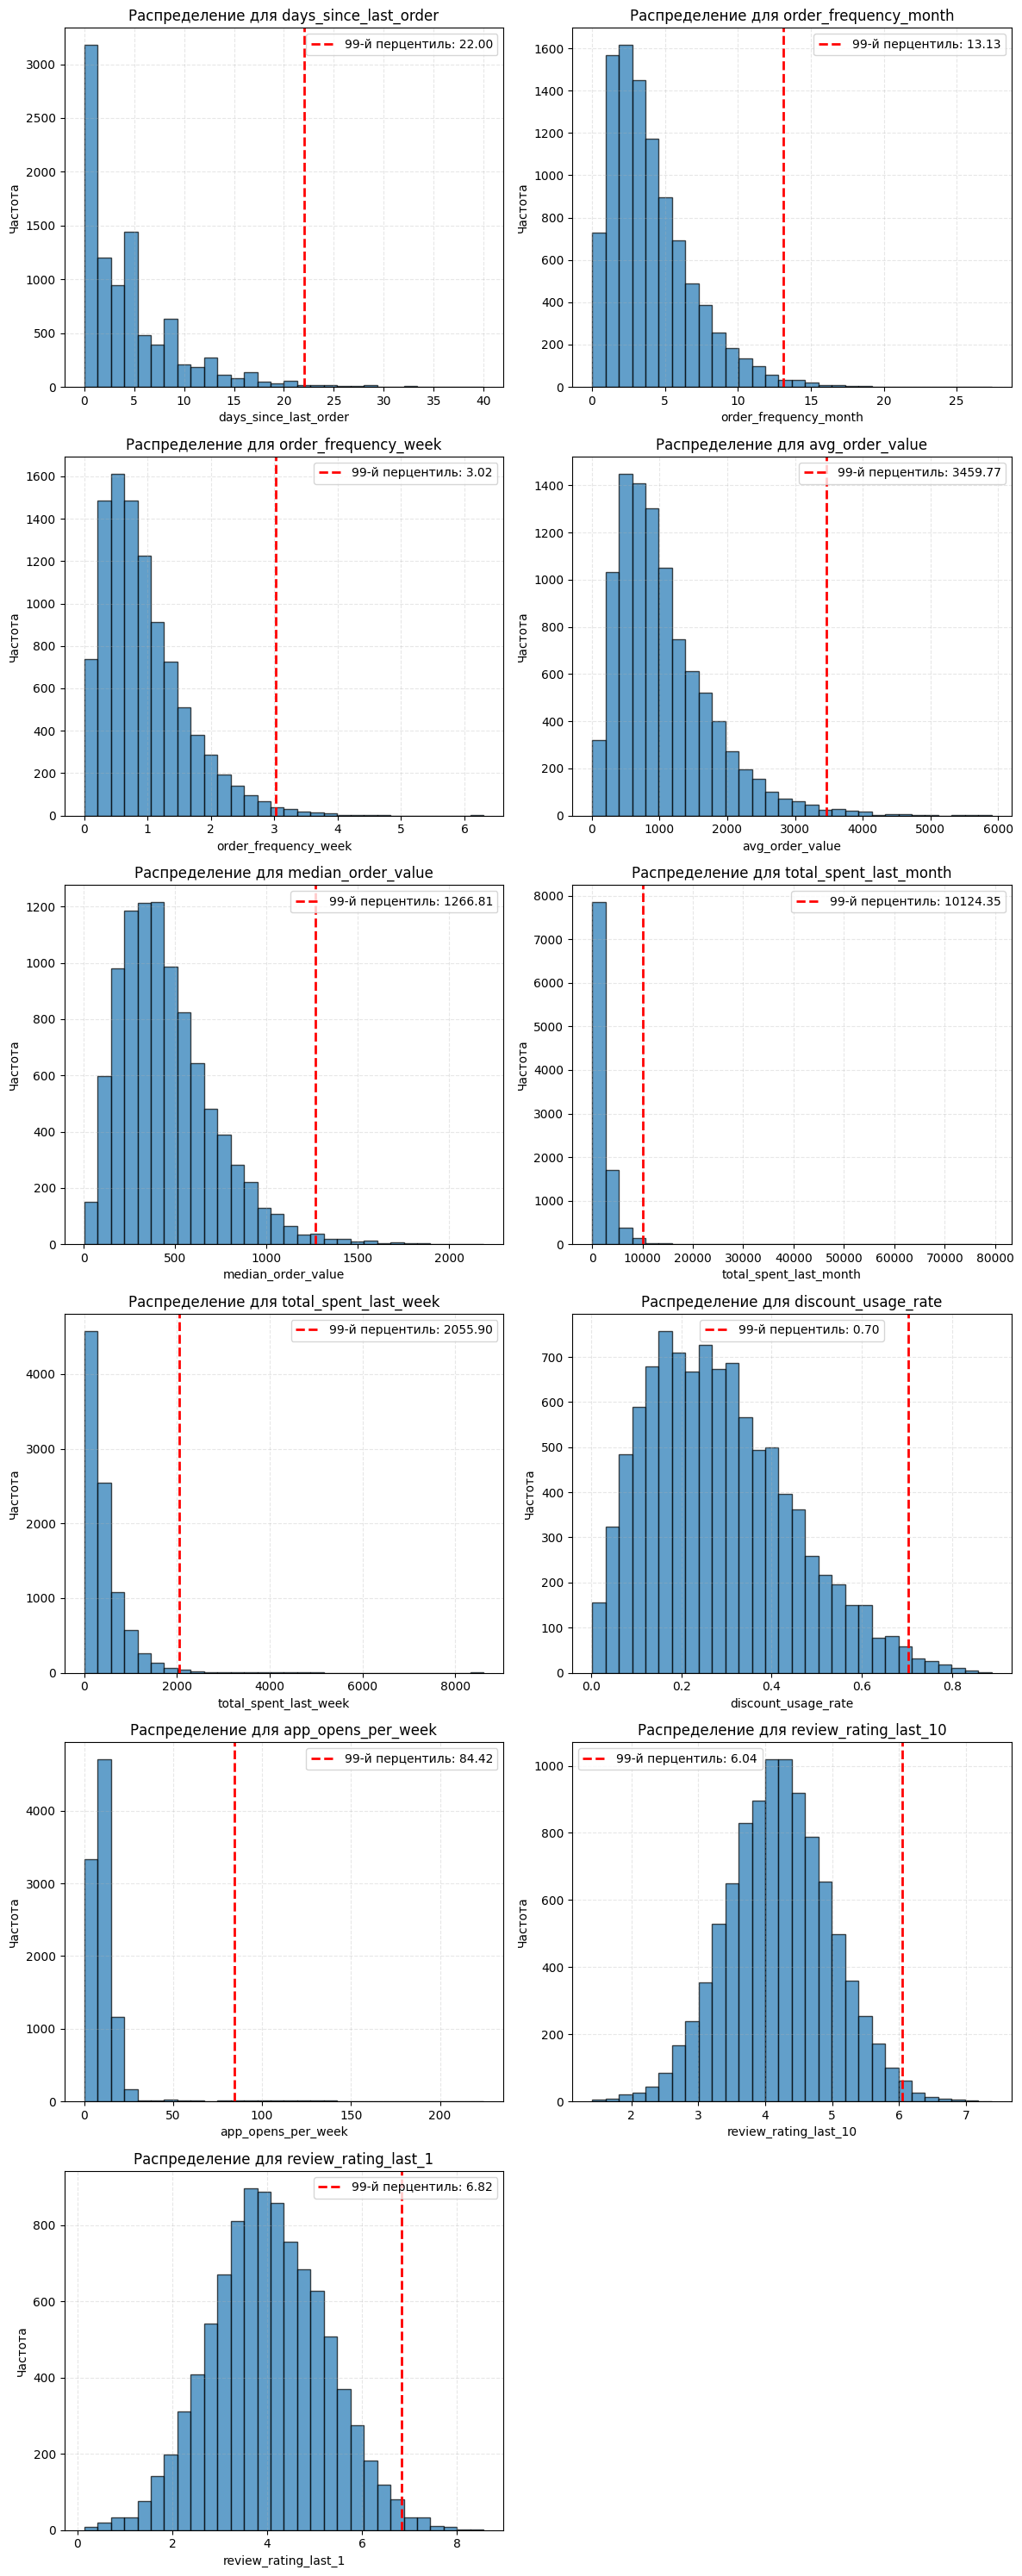

In [43]:
plot_hists(num_continues_features, df, percentile=99)

- распределения  app_opens_per_week, total_spent_last_month, total_spent_last_week имеют существенные выбросы
- распределения 'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value' крайне несимметричны 

Рекомендация:
- для указанных признаков уместно сделать z-score фильтрацию по train выборке


**Анализ выбросов среди дискретных признаков**

In [44]:
# количественные дискретные признаки
num_discrete_features = [
    'seasonal_menu_tried', 'notifications_enabled', 'app_crashes_last_month', 'days_since_last_promo',
    'coffee_preference_change'
]

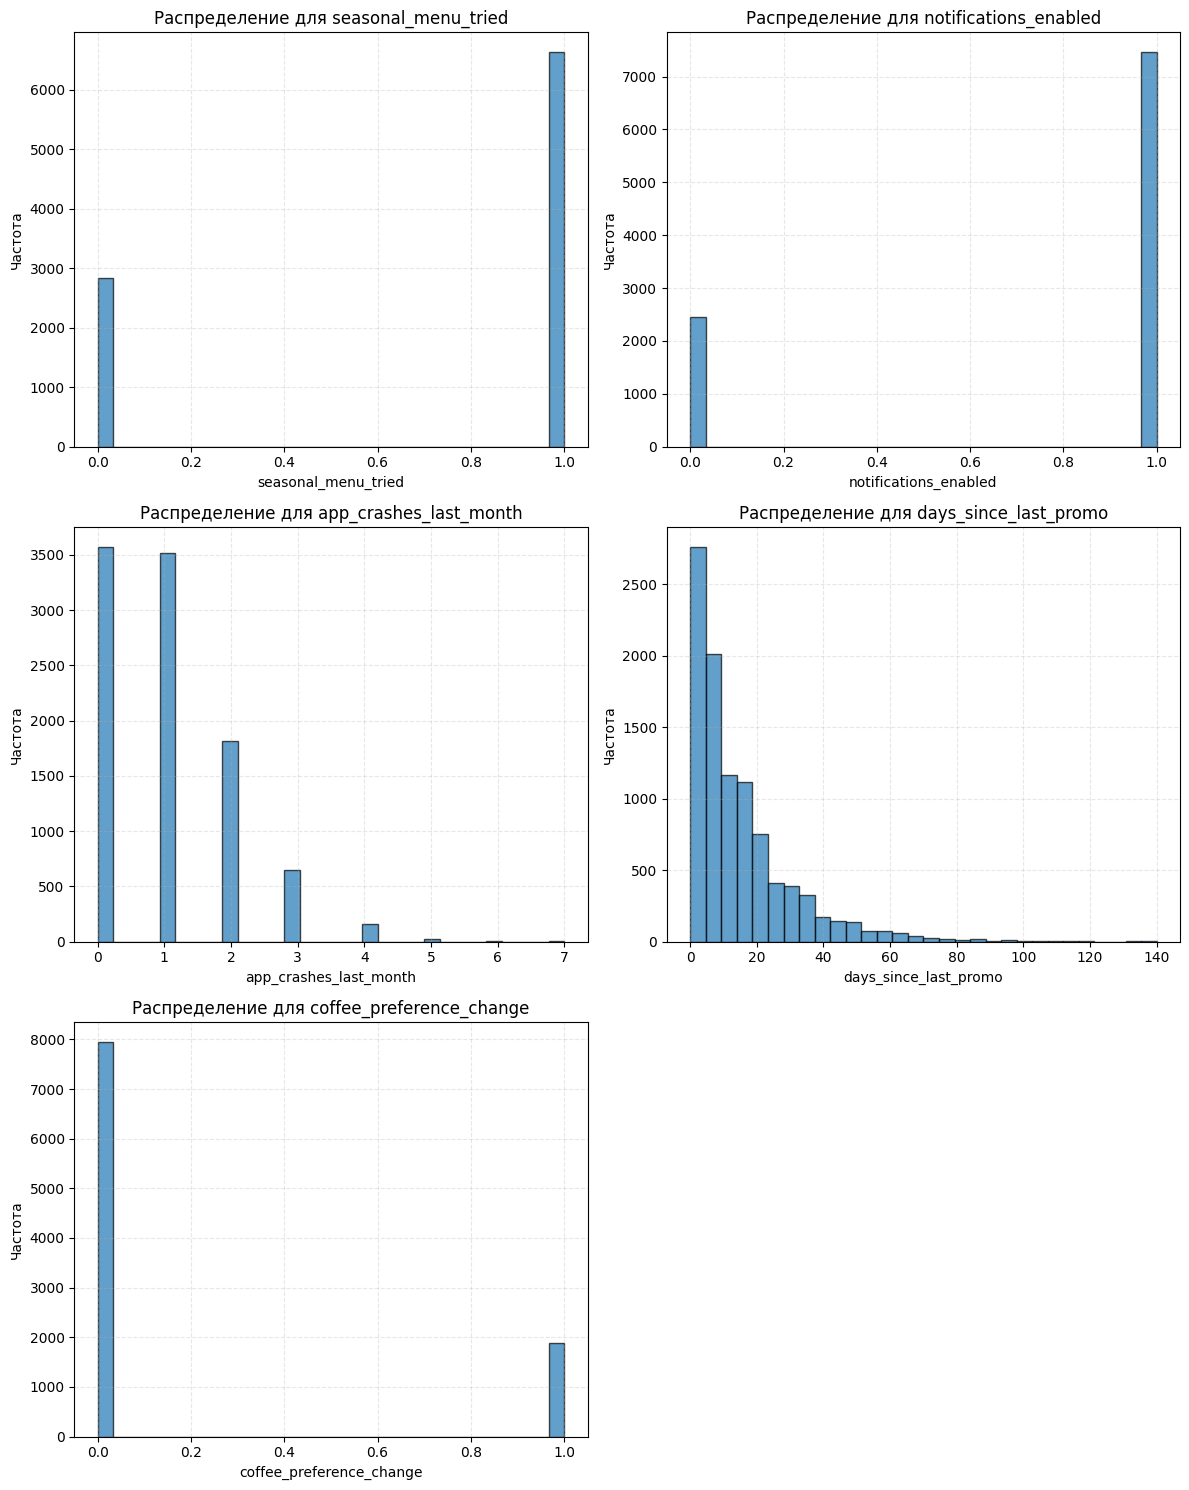

In [45]:
plot_hists(num_discrete_features, df=df)

Анализ:
- распредедение признака days_since_last_promo существенно несимметрично. При построении модели стоит рассмотреть преобразование этого признака логарифмом или корнем

***Итог по анализу выбросов***
- для признаков order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_month, review_rating_last_1 обнаружены ошибки в виде отрицательных значений. Ошибки заменены на пропуски. В дальнейшем будет проведена обработка пропусков на статистики распределений
- для обработки выбросов в непрерырных признаках рекомендовано использовать z-score оценку. Предлагается отфильтровать по 3-сигма порогу с заменой на медиану по train выборке
- для дискретных количественных признаков проведен визуальных анализ распределений. Выявлено, что у признака 'days_since_last_promo' распределение крайне несимметричное. Рекомендуется преобразовать этот признак для улучшеия качества модели

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__


заменяешь выбросы по z-score на всем датасете до разбиения. Это утечка данных
    
    
Замена выбросов на медиану по всему датасету - смещаешь распределение данных (используй какую-либо группировку в зависимости от результатов корреляции например)   

<div class="alert alert-info"> <b>Комментарии студента:</b> Ошибки в виде отрицательных значений теперь заменяю на nan, чтобы обработать как пропуски. z-score фильтрацию и обработку пропусков сделаю после разделения на train/test, чтобы не было утечки данных. </div>

### Анализ распределений среди всех числовых признаков


In [46]:
num_features = num_continues_features + num_discrete_features

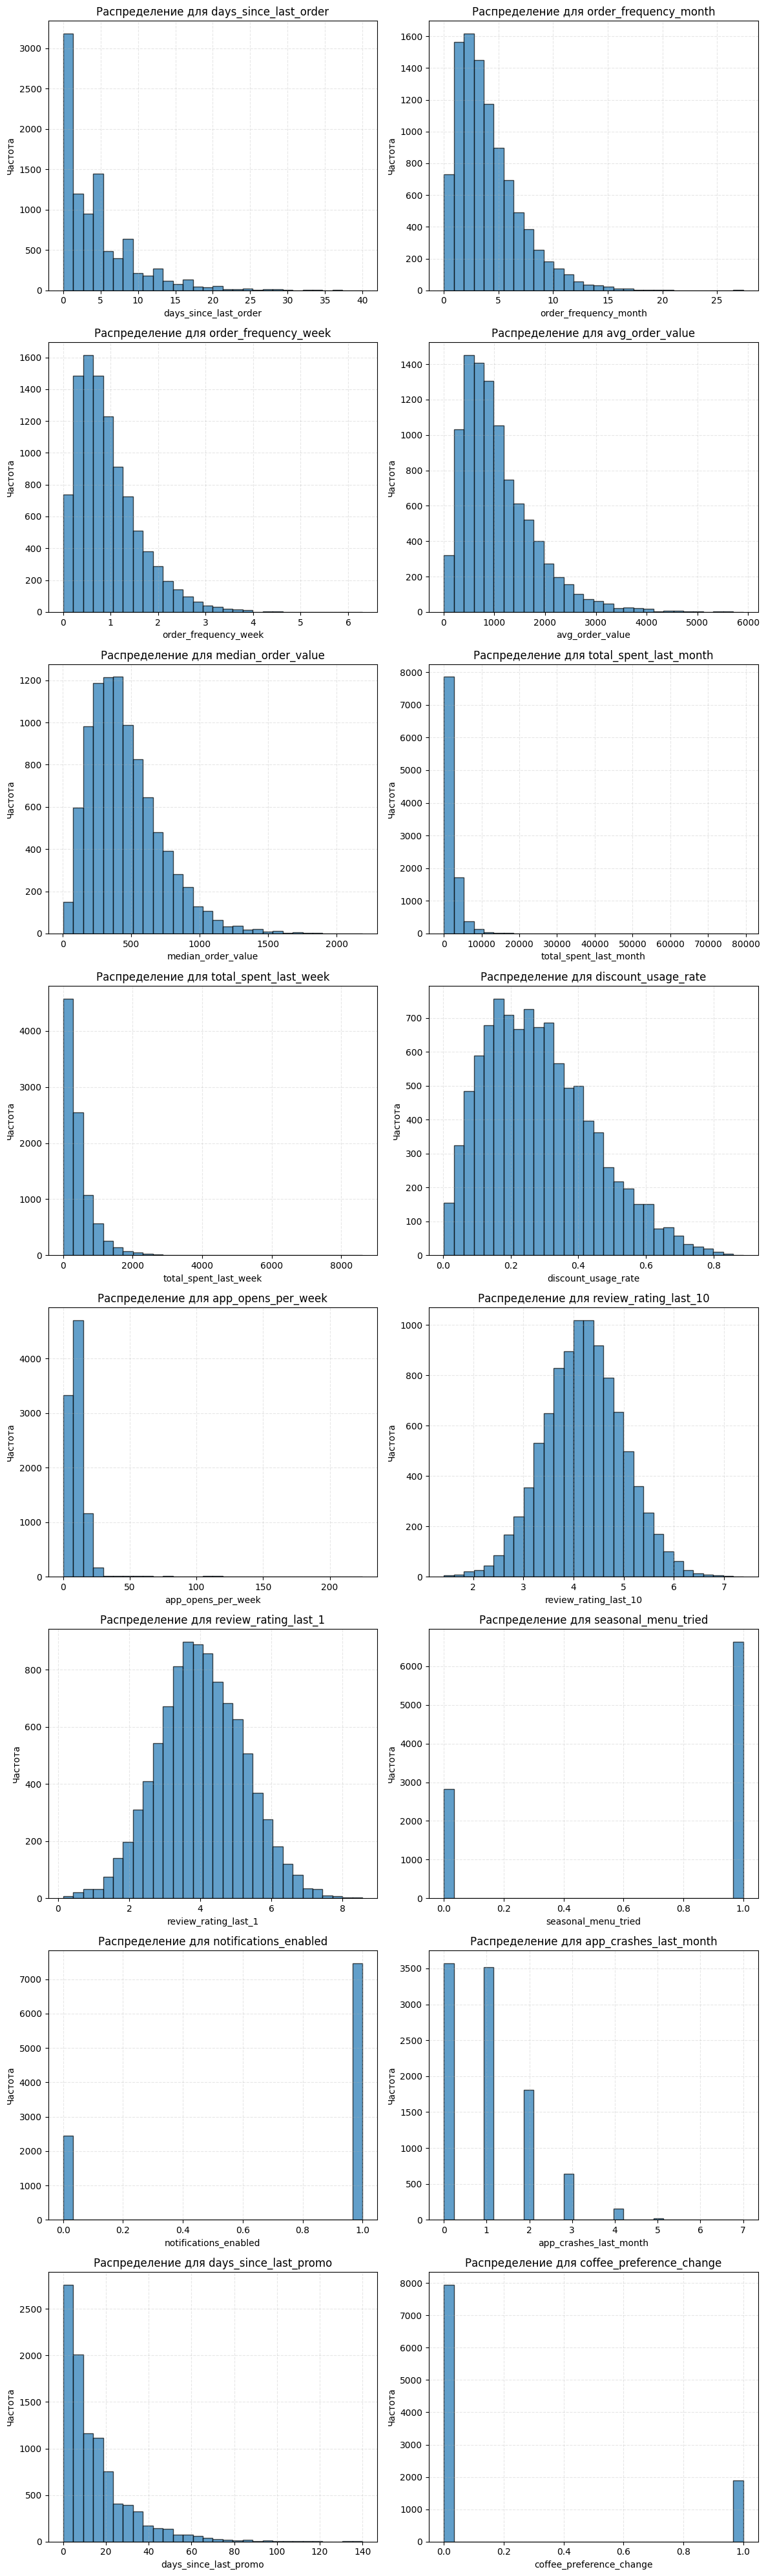

In [47]:
plot_hists(num_features, df=df)

Анализ:
    
- из представленных графиков, видно, что ряд распределений имеет несимметричный вид:
    days_since_last_promo, days_since_last_order, order_frequency_month, total_spend_last_month, total_spend_last_week, app_opens_per_week, app_crashes_last_month
- для приведенных распределений рекомендуется рассмотреть преобразованные признаки. Логарифм или корень поможет сделать более симметричными распределения. Предположительно, это улучшит предсказание линейной модели

### Анализ корреляций между признаками. 

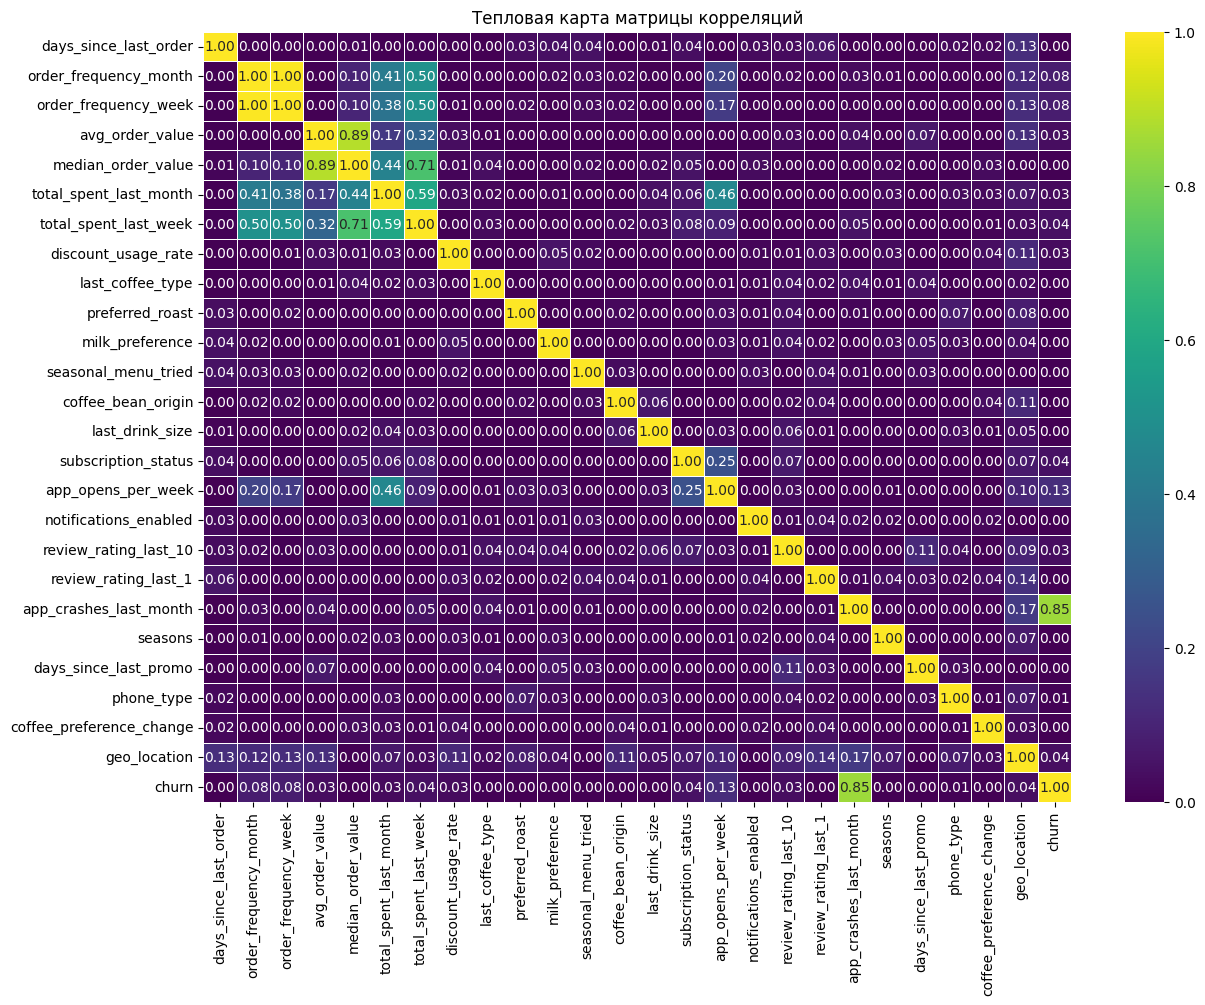

In [48]:
# Посчитаем матрицу корреляций
num_features = num_continues_features + num_discrete_features
corr_matrix = df.phik_matrix(interval_cols=num_features)

# Создаём тепловую  карту
plt.figure(figsize=(14, 10)) 

sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()

Анализ:
- признаки 'order_frequency_month', 'order_frequency_week' сильно скоррелированы (коэффициент 1). С целевой переменной корреляция у них одинаковая, поэтому какой убирать разницы нет.
- признаки 'avg_order_value', 'median_order_value' имеют коэффицент корреляции 0.89. Рекомендуется убрать тот, что меньше коррелирован с целевой переменной: 'median_order_value'.
- остальные признаки не имеют высоких значений корреляции. Оставляем как есть.

Важно:
- удаление признаков проводится после разделения на train/test


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Удаление признаков по корреляции с target на полном датасете - это тоже утечк

<div class="alert alert-info"> <b>Комментарии студента:</b> Оствил только анализ, удаление после разделения на выборки train/test. </div>

### Выводы

1. Анализ целевой переменной:
- Целевая переменная -- бинарный признак [0, 1]. Пропусков нет
- присутствует дисбаланс классов в целевой переменной:
    * 0: 94%
    * 1: 6%

2. Выявление несодержательных признаков и фильрация:
- удален 1 признак, не несущие пользы для дальнейшего анализа и построение модели: user_id (уникальный id пользователя),

3. Анализ пропусков:
    * пропусков нет в целевой переменной
    * особенно много пропусков в subscription_status - 45%, milk_preference - 16%
    * среди остальных признаков количество пропусков варьрируется от 1% до 10%.

    Рекомендация по заполнению пропусков после разделения на train/test:
       * для числовых признаков пропуски заменяем на статистику: медиану. Это позволит избежать смещения распределения при наличии выбросов
       * для категориальных признаков: заменяем на моду (самое часто встечающееся значение)

4. Анализ категориальных признаков.

    Предложена стратегия кодирования категориальных признаков:
    * уникальных значений для признака 'geo_location' 100шт. Используем TargetEncoding для избежания существенного роста количества признаков
    * среди других признаков уникальных значений мало (< 10). Используем One-Hot Encoding
    
    
5. Анализ выбросов

    * для признаков order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_month, review_rating_last_1 - обнаружены ошибки в виде отрицательных значений. Проведена замена на пропуски 
    * для обработки выбросов в непрерырных признаках предлагается использовать z-score оценку с фильтром по 3-сигма
   
6. Преобразование признаков
    
    - распределения days_since_last_promo, days_since_last_order, order_frequency_month, total_spend_last_month, total_spend_last_week, app_opens_per_week имеют скошенный вид. Рекомендуется применить преобразование логарифма/корня, чтобы сделать распределения более симметричными. Предположительно, это улучшит предсказание линейной модели
    
7. Взаимосвязь между признаками

    * признаки 'order_frequency_month', 'order_frequency_week' сильно скоррелированы (коэффициент 1). С целевой переменной корреляция у них одинаковая, поэтому какой убирать разницы нет. Рекомендуется рассмотерть удаление признака 'order_frequency_week'.
    * признаки 'avg_order_value', 'median_order_value' имеют коэффицент корреляции 0.89. Рекомендуется убрать тот, что меньше коррелирован с целевой переменной: 'median_order_value'.
    * остальные признаки не имеют высоких значений корреляции. Оставляем как есть.
    * у призкака app_crashes_last_month особенно высокая корреляция на уровне 0.85 с целевым классом
    
***Итог***:
- данные очищены от неинформативных признаков 
- выбросы в данных обработаны
- сформулированы рекомендации по замене пропусков и применению кодирования категриальных признаков 
- представленые рекомендации по добавлению новых признаков

## Этап 3. Предобработка данных



### Разделение на train/test

In [49]:
X = df.drop(columns='churn')
y = df['churn']
X.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location
0,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,...,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,...,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,...,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,...,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,...,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19


In [50]:
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Разбиение train/test со stratify=y выполнено правильно

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
До разбиения на train/test ты уже удалил признаки, заменил отрицательные значения и обработал выбросы. Это критичная методологическая ошибка, потому что test уже повлиял на подготовку данных
    


<div class="alert alert-info"> <b>Комментарии студента:</b> Устранил утечку данных. Применяю обработку выбросов, фильтрацию после разделения на train/test</div>

### Предобработка данных
- информация о пропусках и категориальных признаках только из обучающей выборки.

In [51]:
# категориальные признаки для One-Hot кодирования.  значений мало (< 10).
cat_one_hot = [
    'last_coffee_type', 'preferred_roast', 
    'milk_preference', 'last_drink_size', 
    'phone_type', 'subscription_status'
]
# Категориальные для Target кодирования. значений много (> 10)
cat_target_encode = [
    'geo_location'
]
# Численные непрерывные признаки
num_continues_features = [
 'order_frequency_month', 'avg_order_value',
    'total_spent_last_month', 'app_opens_per_week',
    'total_spent_last_week', 'discount_usage_rate',
    'review_rating_last_10', 'review_rating_last_1', 
]
# Численные дискретные признаки
num_special_features = [
    'seasonal_menu_tried', 'notifications_enabled', 'app_crashes_last_month', 'days_since_last_promo',
    'coffee_preference_change', 'days_since_last_order', 
]

In [52]:
class ZScoreOutlierReplacer(BaseEstimator, TransformerMixin):
    def __init__(self, z_threshold: float = 3.0):
        self.z_threshold = z_threshold

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.means_ = np.nanmean(X, axis=0)
        self.stds_ = np.nanstd(X, axis=0)
        self.medians_ = np.nanmedian(X, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()

        # избегаем деления на 0
        safe_stds = np.where(self.stds_ == 0, 1, self.stds_)
        z = np.abs((X - self.means_) / safe_stds)

        outlier_mask = z > self.z_threshold
        X[outlier_mask] = np.take(self.medians_, np.where(outlier_mask)[1])
        return X


def replace_zscore_outliers_with_median(z_threshold: float = 3.0):
    return ZScoreOutlierReplacer(z_threshold=z_threshold)


In [53]:
# Пайплайны
cat_one_hot_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

cat_target_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

num_continues_pipeline = Pipeline(steps=[
    ('outliers', replace_zscore_outliers_with_median(z_threshold=3.0)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_special_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

In [54]:
# Общий трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_one_hot', cat_one_hot_pipeline, cat_one_hot),
        ('cat_target', cat_target_pipeline, cat_target_encode),
        ('num_continues', num_continues_pipeline, num_continues_features),
        ('special', num_special_pipeline, num_special_features)
    ],
)

In [55]:
def get_feature_names(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        # 1) Пропускаем удаленные колонки
        if transformer == 'drop':
            continue

        # 2) passthrough -> имена как есть
        if transformer == 'passthrough':
            feature_names.extend(columns)
            continue

        # 3) если pipeline, берем последний шаг
        if hasattr(transformer, 'steps'):
            last_step = transformer.steps[-1][1]
        else:
            last_step = transformer

        if isinstance(last_step, OneHotEncoder):
            names = last_step.get_feature_names_out(columns)
        elif isinstance(last_step, TargetEncoder):
            names = [f'{col}_target_encoded' for col in columns]
        else:
            names = columns

        feature_names.extend(names)

    return feature_names


In [56]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    """
    Предобработчик данных с корректным преобразованем имен столбцов
    """
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        self.preprocessor_.fit(X, y)
        self.feature_names_ = get_feature_names(self.preprocessor_)
        return self

    def transform(self, X):
        transformed = self.preprocessor_.transform(X)
        X_transformed = pd.DataFrame(
            transformed,
            columns=self.feature_names_,
            index=X.index
        ).reset_index(drop=True)
        return X_transformed

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)



<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__
    
отдельно вызываешь preprocessor.fit_transform(X_train, y) и строишь X_train_transformed, а потом уже используешь CV на готовой матрице признаков. Это утечка внутри кросс-валидации, поскольку кодировщики, импьютеры и scaler уже обучены на всем train до разбиения на фолды
    
    
    
Кстати, для TargetEncoder это особенно критично, потому что он использует target при кодировании. В этом проекте вся предобработка должна оцениваться только внутри полного pipeline во время CV, а не на заранее подготовленных данных.

<div class="alert alert-info"> <b>Комментарии студента:</b> Оставил только формирование пайплайнов предобработки данных. Буду ее вызывать в cv</div>

## Этап 4. Обучение модели


### Обучение базовой модели

In [57]:
basic_logreg_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

In [58]:
# Базовый Пайплайн преодобработки и обучения
pipeline_basic = Pipeline([
    ('prep', CustomPreprocessor(preprocessor)),
    ('basic_logreg_model', basic_logreg_model)
])

In [59]:
# Пайплайн с DummyClassifier для сравнения
pipeline_dummy = Pipeline([
    ('prep', CustomPreprocessor(preprocessor)),
    ('basic_logreg_model', DummyClassifier(random_state=RANDOM_STATE))
])

### Кросс-валидация

In [60]:
N_FOLDS = 5

# Настройка кросс-валидации
# классы несбалансированы, применяем стратификацию
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)  

In [61]:
# Получаем вероятности положительного класса через кросс-валидацию
y_proba_default = cross_val_predict(pipeline_basic, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]

In [62]:
# Dummy 
y_proba_dummy = cross_val_predict(pipeline_dummy, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]

In [63]:
def plot_pr_auc_curve(y_train, y_probas: list[pd.Series], labels: list[str]):
    plt.figure(figsize=(14, 10)) 
    
    for y_proba, label in zip(y_probas, labels):
        # PR-кривая и AUC
        precision, recall, _ = precision_recall_curve(y_train, y_proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, lw=2, label=f'{label}. AP = {pr_auc:.3f}')

    
    baseline = sum(y_train) / len(y_train)
    plt.axhline(y=baseline, color='k', linestyle='--', 
                label=f'Случайный классификатор (AP = {baseline:.3f})', linewidth=1)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (cross-validation)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()


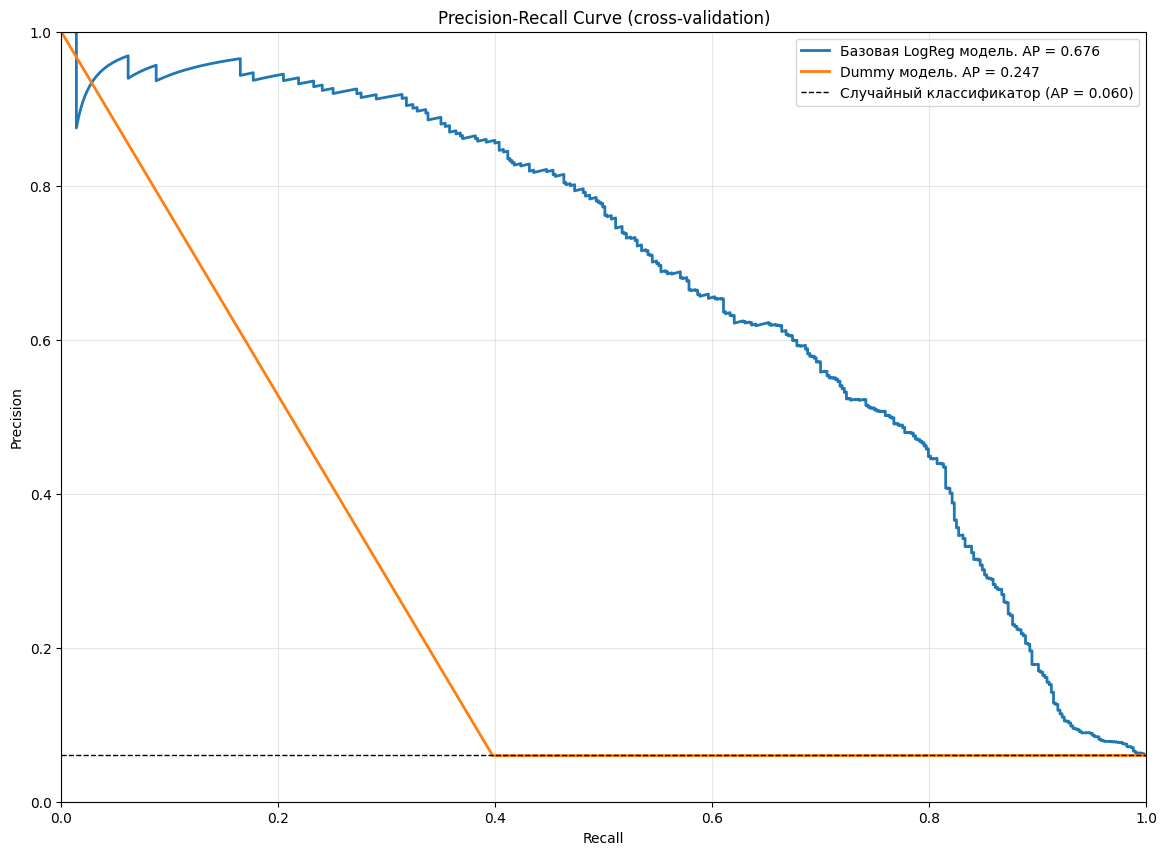

In [64]:
plot_pr_auc_curve(y_train, [y_proba_default, y_proba_dummy], labels=['Базовая LogReg модель', 'Dummy модель'])

###### **Анализ:**
- для базовой модели ключевая метрика PR-AUC составила 0.676. Исходя из принятых ориентиров для этой метрики, модель можно применять к предсказанию целевой метрики.
- показатель PR-AUC = 0.676 > 0.5 свидетельствует о хорошей предсказательной способности модели
- базовая модель существенно лучше Dummy: PR-AUC = 0.247



<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Правильно, что выбрал логистическую регрессию как базовую модель

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__



применяешь cross_val_predict не к полному pipeline, а к одной только модели на заранее подготовленных признаках

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Отсутствует baseline через DummyClassifier, хотя это требование хорошей ML-практики

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Хорошо бы добавить несколько метрик базовой модели кроме PR AUC

<div class="alert alert-info"> <b>Комментарии студента:</b> 

Внес исправления: 

- применяю cross_val_predict к полному pipeline.
- добавил Dummy модель

</div>

## Этап 5. Создание новых признаков


### Добавление новых признаков

***Рекомендации по результатам анализа данных:***

- распределения days_since_last_promo, days_since_last_order, order_frequency_month, total_spent_last_month, total_spent_last_week, app_opens_per_week имеют несимметричный вид. Рекомендуется применить преобразование логарифмом/корнем, чтобы сделать распределения более симметричными.
- исходя из плотности распределений внутри признака app_crashes_last_month рассмотрим биннинг: <=2, >=3
- признак app_crashes_last_month высоко коррелирует с целевым классом. Предположительно, клиенты перестают быть лояльными, если у них большое количество отказов приложения. Имеет смысл усилить влияние большого количества отказов с помощью возведения в степень.

In [65]:
def create_log1p_feature(data: pd.DataFrame, name: str):
    data_upd = data.copy()
    data_upd[f"{name}_log1p"] = np.log1p(data_upd[name])
    
    return data_upd, f"{name}_log1p"

def create_pow2_feature(data: pd.DataFrame, name: str):
    data_upd = data.copy()
    data_upd[f"{name}_pow2"] = data_upd[name]**2
    
    return data_upd, f"{name}_pow2"

def create_binary_binned_feature(data: pd.DataFrame, name: str, border: int):
    data_upd = data.copy()
    one_mask = data_upd[name] >= border
    data_upd[f'{name}_binned'] = 0
    data_upd.loc[one_mask, f'{name}_binned'] = 1

    return data_upd, f'{name}_binned'

In [66]:
cols_to_log1p_transform = [
    'order_frequency_month', 
    'total_spent_last_month',
    'total_spent_last_week',
    'avg_order_value', 
    'app_opens_per_week'
]
cols_to_pow2_transform = [
    'app_crashes_last_month'
]
cols_to_binary_bin_transform = [
    'app_crashes_last_month'
]

In [67]:
X_train_new_features = X_train.copy()
new_names = []
for name in cols_to_log1p_transform:
    X_train_new_features, new_name = create_log1p_feature(X_train_new_features, name)
    new_names.append(new_name)

for name in cols_to_pow2_transform:
    X_train_new_features, new_name = create_pow2_feature(X_train_new_features, name)
    new_names.append(new_name)

for name in cols_to_binary_bin_transform:
    X_train_new_features, new_name = create_binary_binned_feature(X_train_new_features, name, border=3)
    new_names.append(new_name)

In [68]:
X_train_new_features.columns

Index(['days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'last_coffee_type', 'preferred_roast',
       'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin',
       'last_drink_size', 'subscription_status', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 'seasons',
       'days_since_last_promo', 'phone_type', 'coffee_preference_change',
       'geo_location', 'order_frequency_month_log1p',
       'total_spent_last_month_log1p', 'total_spent_last_week_log1p',
       'avg_order_value_log1p', 'app_opens_per_week_log1p',
       'app_crashes_last_month_pow2', 'app_crashes_last_month_binned'],
      dtype='str')

In [69]:
def create_new_features(X: pd.DataFrame):
    X_upd = X.copy()
    cols_to_log1p_transform = [
        'order_frequency_month', 
        'total_spent_last_month',
        'total_spent_last_week',
        'avg_order_value', 
        'app_opens_per_week'
    ]
    cols_to_pow2_transform = [
        'app_crashes_last_month'
    ]
    cols_to_binary_bin_transform = [
        'app_crashes_last_month'
    ]
    new_names = []
    for name in cols_to_log1p_transform:
        X_upd, new_name = create_log1p_feature(X_upd, name)
        new_names.append(new_name)

    for name in cols_to_pow2_transform:
        X_upd, new_name = create_pow2_feature(X_upd, name)
        new_names.append(new_name)

    for name in cols_to_binary_bin_transform:
        X_upd, new_name = create_binary_binned_feature(X_upd, name, border=3)
        new_names.append(new_name)

    return X_upd

In [70]:
X_train_new_features = create_new_features(X_train)
X_train_new_features.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,phone_type,coffee_preference_change,geo_location,order_frequency_month_log1p,total_spent_last_month_log1p,total_spent_last_week_log1p,avg_order_value_log1p,app_opens_per_week_log1p,app_crashes_last_month_pow2,app_crashes_last_month_binned
5424,0.0,5.692281,1.217881,247.094840,167.145725,775.622066,215.690836,0.332092,blend,dark,...,android,1.0,geo_47,1.900955,6.654954,5.378472,5.513811,2.889656,0.0,0
9973,5.0,3.082845,0.706661,1398.572719,482.760307,1574.378165,331.867477,0.166546,arabica,light,...,ios,0.0,geo_2,1.406794,7.362251,5.807744,7.243922,2.049873,0.0,0
9137,NaN,3.960048,1.038997,1349.529379,418.772312,1558.873026,479.701166,0.068832,blend,dark,...,android,1.0,geo_36,1.601415,7.352360,6.175246,7.208252,NaN,0.0,0
2379,NaN,3.206888,0.763252,2039.899879,929.571103,3029.532022,920.152116,0.257449,arabica,medium,...,ios,0.0,geo_91,1.436723,8.016493,6.825625,7.621146,NaN,0.0,0
7631,2.0,2.615352,0.610830,342.874409,264.877659,636.928615,NaN,0.275780,robusta,medium,...,ios,0.0,geo_78,1.285189,6.458226,NaN,5.840277,2.498583,NaN,0


### Анализ новых признаков


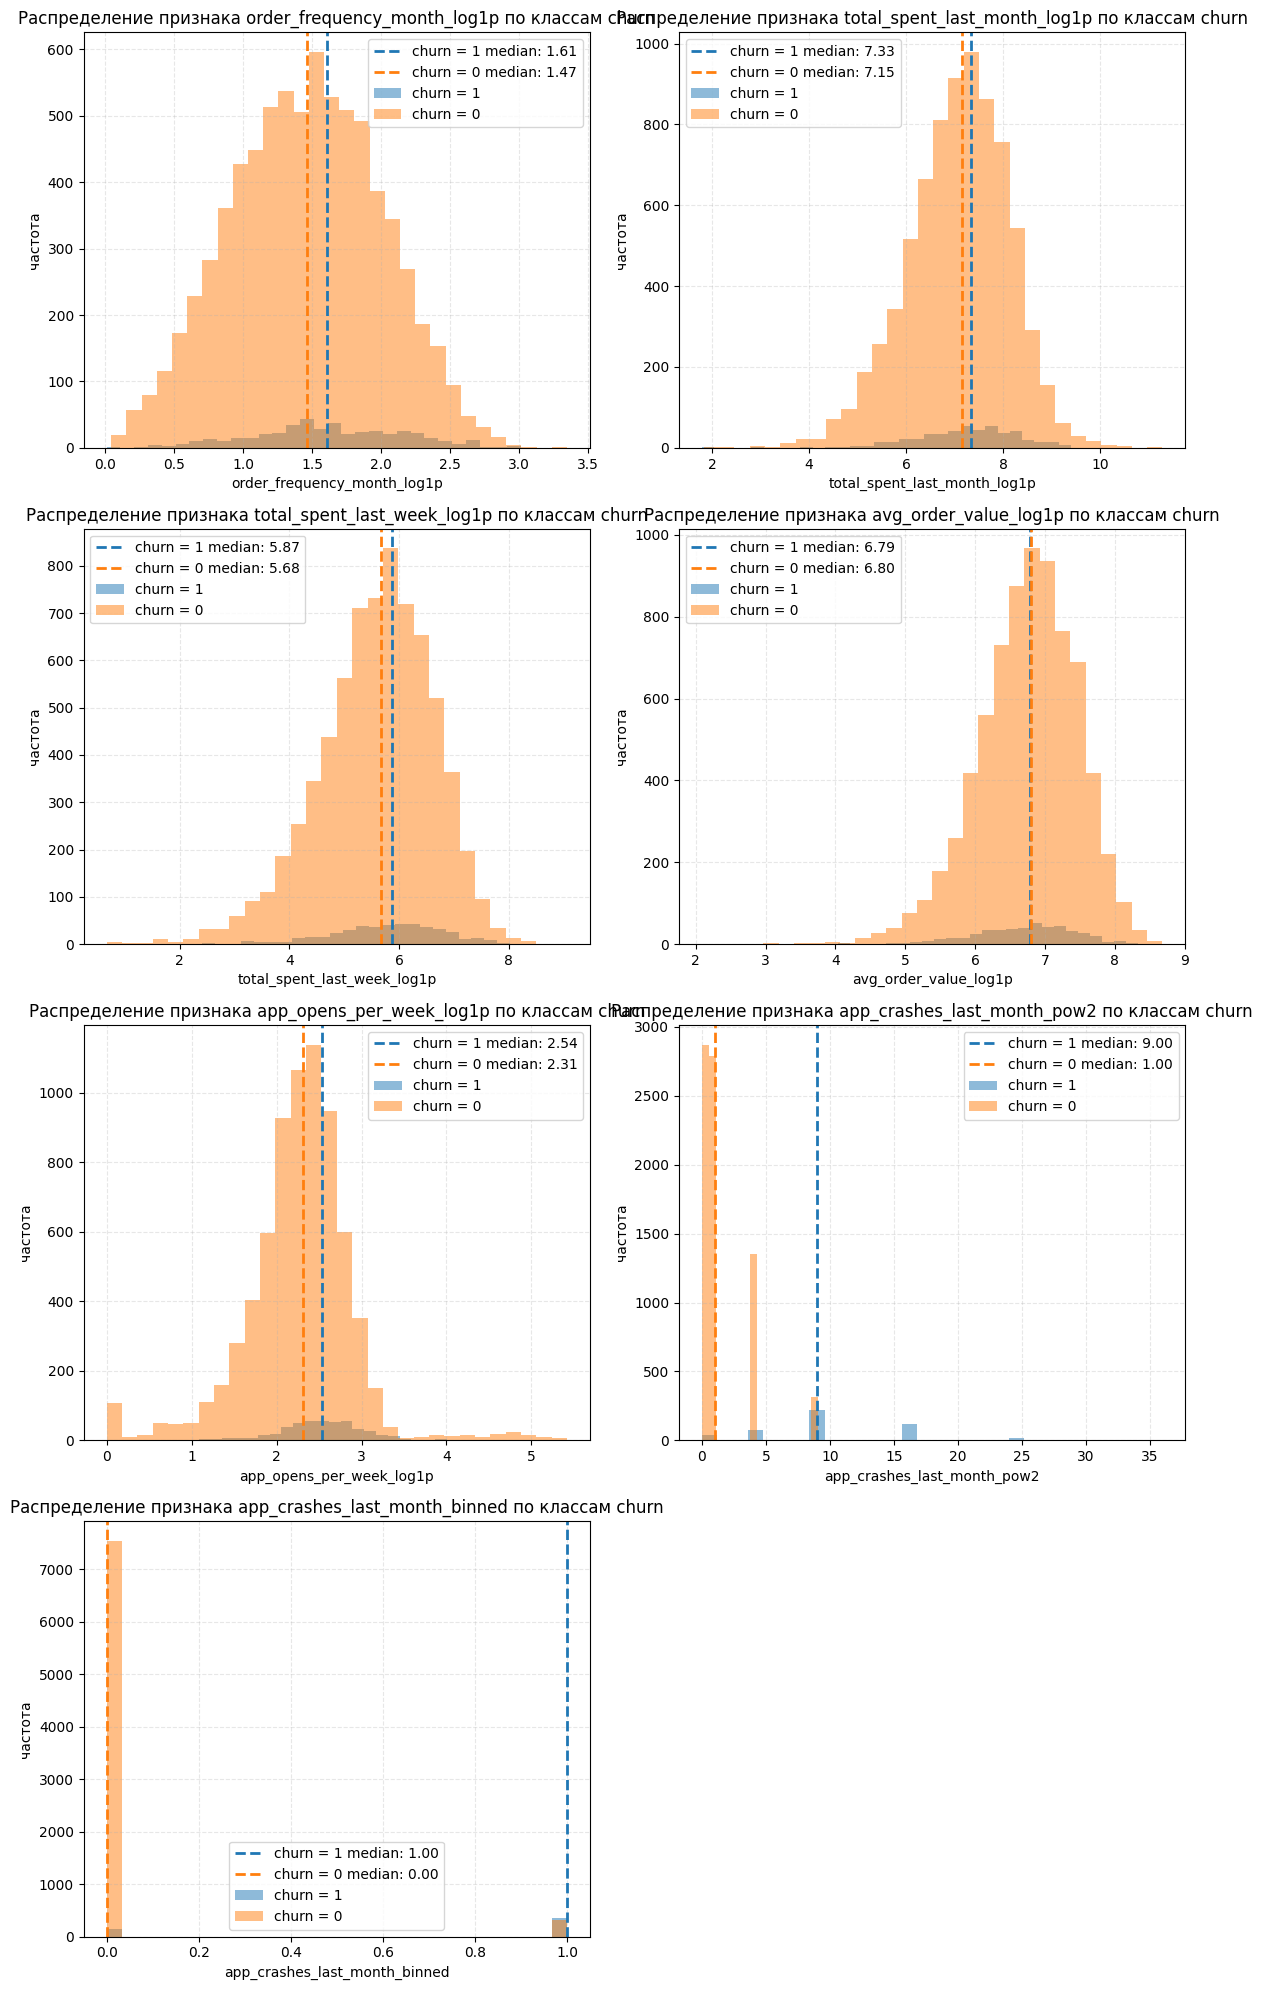

In [71]:
plot_target_class_dist(feature_names_list=new_names, df=pd.concat([X_train_new_features, y_train], axis=1), density=False)

Анализ:
- логарифм сделал распределения более симметричными. 
- Возведение в степень и биннинг помогло отделить распределения по признаку churn

### Обучение и сравнение с базовой моделью

In [72]:
# Обновление трансформера новыми признаками

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_one_hot', cat_one_hot_pipeline, cat_one_hot),
        ('cat_target', cat_target_pipeline, cat_target_encode),
        ('num_continues', num_continues_pipeline, num_continues_features + new_names),
        ('special', num_special_pipeline, num_special_features)
    ],
)

In [ ]:
# Обучение на новых признаках
# Получаем вероятности положительного класса через кросс-валидацию
y_proba_new_feat = cross_val_predict(
    pipeline_basic, X_train_new_features, y_train, cv=kfold, method='predict_proba'
)[:, 1]

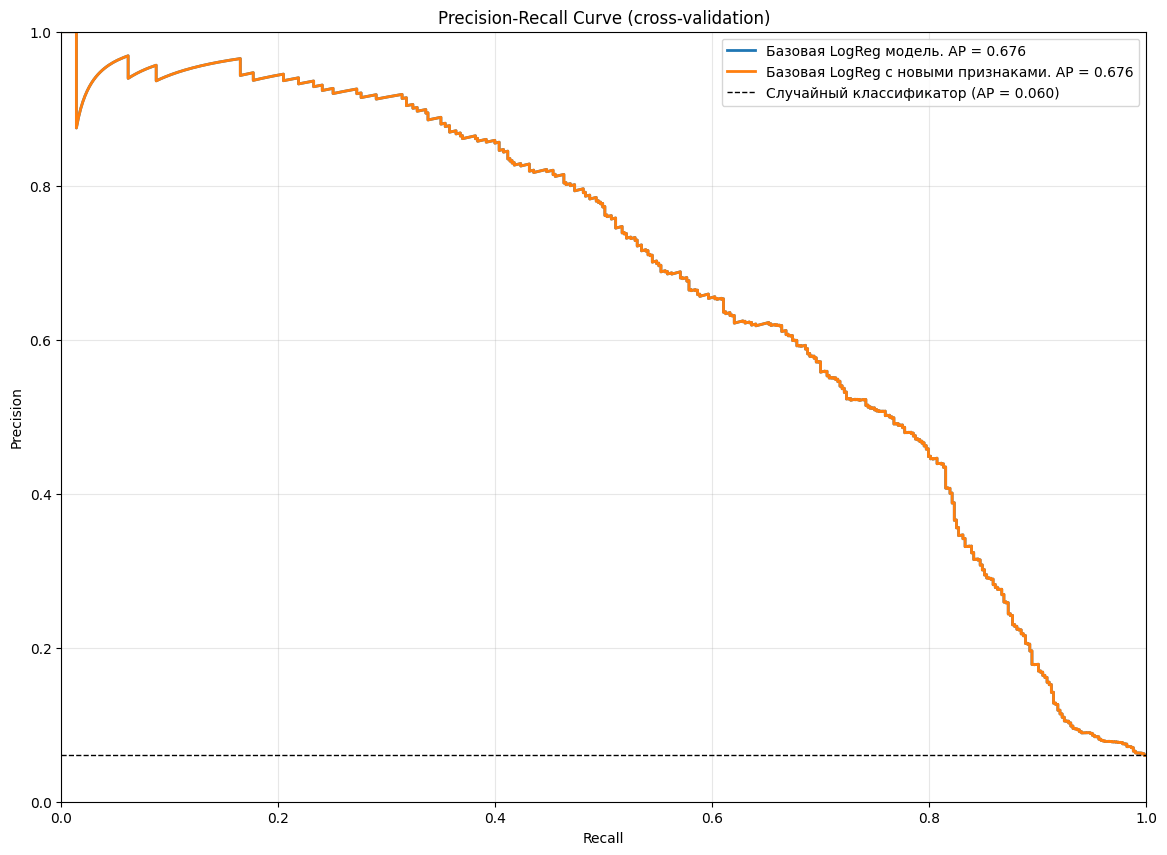

In [75]:
plot_pr_auc_curve(
    y_train, 
    [y_proba_default, y_proba_new_feat], labels=['Базовая LogReg модель', 'Базовая LogReg с новыми признаками']
)

Анализ:
- добавленные признаки позволили улучшить качество модели на 8% относительно базовой. Новое значение PR-AUC = 0,722

### Интерпретация коэффициентов модели

In [59]:
# обучение базовой модели с новыми признаками
model = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE
)
model.fit(X_train_transformed, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [60]:
# выявление значимых признаков
coef = pd.Series(model.coef_[0], index=feature_names)

# важность
importance = coef.abs().sort_values(ascending=False)


result = pd.DataFrame({
    'coef': coef,
    'abs_coef': importance,
}).sort_values('abs_coef', ascending=False)

result[:20]

,coef,abs_coef
geo_location_target_encoded,2.747208,2.747208
app_crashes_last_month_pow2,2.676755,2.676755
app_opens_per_week_log1p,1.772481,1.772481
app_crashes_last_month,-0.916958,0.916958
app_opens_per_week,-0.739032,0.739032
subscription_status_pro,0.520966,0.520966
milk_preference_almond,0.377027,0.377027
seasonal_menu_tried,-0.369650,0.369650
subscription_status_basic,-0.338093,0.338093
milk_preference_none,-0.336303,0.336303


In [61]:
# топ самых значимых
top_number = 15

important_features = list(result[:top_number].index)
important_features

['geo_location_target_encoded',
 'app_crashes_last_month_pow2',
 'app_opens_per_week_log1p',
 'app_crashes_last_month',
 'app_opens_per_week',
 'subscription_status_pro',
 'milk_preference_almond',
 'seasonal_menu_tried',
 'subscription_status_basic',
 'milk_preference_none',
 'phone_type_web',
 'total_spent_last_month',
 'phone_type_android',
 'last_coffee_type_robusta',
 'last_coffee_type_arabica']

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Хорошо, что сравнил базовую модель и модель с новыми признаками

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
десь снова повторяется та женеточность: у тебя новые признаки создаются заранее, затем preprocessor обучается на всем train, и только после этого делается CV. Это утечка
    
Для этого этапа новые признаки должны добавляться внутри pipeline через FunctionTransformer, а дальше весь pipeline должен целиком участвовать в кросс-валидации

## Этап 6. Эксперименты с гиперпараметрами



### Перебор гиперпараметров
- C - коэффициент регуляризации
- penalty - Тип регуляризации
- class_weight - учет бисбаланса классов
- max_iter - сходимость

In [62]:
logreg = LogisticRegression(
    random_state=RANDOM_STATE
)

In [63]:
# Параметры для перебора
param_grid = [
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'class_weight': [None, 'balanced'],
        'max_iter': [500, 1000]
    },
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'class_weight': [None, 'balanced'],
        'max_iter': [500, 1000]
    },
]

In [64]:
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='average_precision',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_transformed, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая метрика:", grid_search.best_score_)
best_model = grid_search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che

Лучшие параметры: {'C': 100, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2'}
Лучшая метрика: 0.7355678880991663


In [65]:
best_model

LogisticRegression(C=100, max_iter=500, random_state=42)

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Подбор гиперпараметров выполнен не на полном pipeline, а на заранее подготовленных признаках

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
В GridSearchCV ты включил penalty='l1', но не задал совместимый solver в сетке. По умолчанию используется lbfgs, который l1 не поддерживает. Из-за этого часть перебора просто упала с nan (не забываем читать warning)  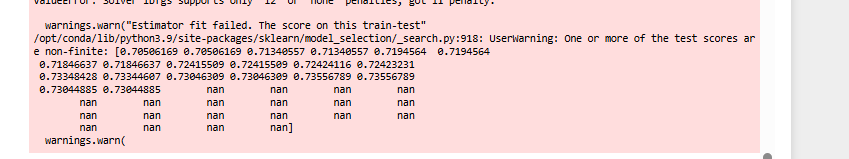

## Этап 7. Подготовка финальной модели

### Лучшая модель

In [66]:
best_model = LogisticRegression(
    C=100,
    max_iter=500,
    penalty='l1',
    random_state=42,
    solver='liblinear'
)

### Признаки

In [67]:
# Обновление трансформера новыми признаками
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_one_hot', cat_one_hot_pipeline, cat_one_hot),
        ('cat_target', cat_target_pipeline, cat_target_encode),
        ('num_continues', num_continues_pipeline, num_continues_features + new_names),
        ('special', num_special_pipeline, num_special_features)
    ]
)
# применение трансформера

def apply_preprocessor(preprocessor, X, y_train):
    transformed = preprocessor.fit_transform(X, y_train)

    feature_names = get_feature_names(preprocessor)

    X_transformed = pd.DataFrame(
        transformed,
        columns=feature_names,
        index=X.index
    )
    return X_transformed

In [68]:
# отбор важных признаков после трансформации
def select_important_features_df(X):
    X_df = pd.DataFrame(X, columns=all_feature_names_after_preprocessing)
    return X_df[important_features]


In [69]:
X_train_new_features = create_new_features(X_train)
X_train_transformed = preprocessor.fit_transform(X_train_new_features, y_train)
all_feature_names_after_preprocessing = get_feature_names(preprocessor)

In [70]:
# Финальный pipeline
final_pipeline = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(create_new_features, validate=False)),
    ('preprocessor', preprocessor),
    ('selector', FunctionTransformer(select_important_features_df, validate=False)),
    ('model', best_model)
])

### Обучение 

In [71]:
# Настройка кросс-валидации
# метрика pr-auc
scoring = ['average_precision'] 
N_FOLDS = 5
# классы несбалансированы, применяем стратификацию
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)  

In [72]:
# кросс-валидация для улучшенной модели на отобранном наборе признаков
cv_results = cross_validate(
    final_pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=kfold
)

In [73]:
enhanced_means = {
    "pr_auc":cv_results["test_average_precision"].mean(),
}
enhanced_means

{'pr_auc': 0.7169044715937332}

In [74]:
# Обучение финального пайплайна 
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function create_new_features at 0x7f77e4046040>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('cat_one_hot',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['last_coffee_type',
                                                   'preferred_roast',
                                                   'mi...
                                                                                 strategy='constant

In [75]:
# Предсказания на тесте
y_test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = final_pipeline.predict(X_test)

In [76]:
# финальная метрика
final_pr_auc = average_precision_score(y_test, y_test_pred_proba)

In [77]:
print("Финальные результаты на тестовой выборке:")
print("-" * 45)
print(f"PR-AUC:   {final_pr_auc:.3f}")

print("\nСравнение с кросс-валидацией:")
print("-" * 45)
print(f"{'Метрика':<12} {'CV':<12} {'Test':<12} {'Разница':<10}")
print("-" * 45)

test_results_final = {"pr_auc": final_pr_auc}

for metric in ["pr_auc"]:
    cv_mean = enhanced_means[metric]
    test_score = test_results_final[metric]
    diff = test_score - cv_mean

    print(f"{metric.upper():<12} {cv_mean:<12.3f} {test_score:<12.3f} {diff:+.3f}")

Финальные результаты на тестовой выборке:
---------------------------------------------
PR-AUC:   0.710

Сравнение с кросс-валидацией:
---------------------------------------------
Метрика      CV           Test         Разница   
---------------------------------------------
PR_AUC       0.717        0.710        -0.007


Анализ:
- метрика PR_AUC незначительно уменьшилась на тесте по сравнению с кросс-валидацией, что свидетельствует об отсутствии переобучения и хорошей предсказательной способности модели

## Этап 8. Отчёт о проделанной работе


В рамках подготовки данных к обучению была проведена фильтрация выбросов, масштабирование числовых признаков и кодирование категориальных признаков.

На преобработанных данных была обучена базовая модель логистической регрессии. Модель показала хорошее значение ключевой метрики на тренирвочных данных: PR-AUC=0,668.

Проведены преобразования признаков для улучшения качества предсказаний: симметризация распределений с помощью логиарифма и выделение экстремальных значений для сильно коррелированного с итоговым классом признака. Приведенное преобразование признаков позволило повысить качество предсказаний модели на 8% относительно базовой. Новое значение PR-AUC = 0,722

Проведена оптимизация параметров модели и выявлены наиболее подходящие гиперпараметры: 
- LogisticRegression(C=100, max_iter=500, penalty='l1', random_state=42, solver='liblinear')
- ключевая метрика повысилась до PR-AUC = 0.73 (+1% прирост)

Проведен отбор топ 15 наиболее важных признаков

Метрики итоговой модели (преобразованные, наиболее важные признки + оптимизированные гиперпараметры):
- CV: PR_AUC = 0.717
- test: PR_AUC = 0.710

По итогам проведенных улучшений базовой модели можно сделать вывод том, что наибольший прирост по качеству модели принесли именно преобразования признаков: +8% к ключевой метрике. 

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Поправь, пожалуйста, выводы после корректировки

## Этап 9. Сохранение модели для продакшена

Сохранение:

In [78]:
joblib.dump(final_pipeline, 'logreg_final_pipeline.joblib')

['logreg_final_pipeline.joblib']

Проверка:

In [79]:
loaded_pipeline = joblib.load('logreg_final_pipeline.joblib')

y_pred_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
y_pred = loaded_pipeline.predict(X_test)

In [80]:
y_pred_proba

array([0.06735816, 0.07153639, 0.01108717, ..., 0.05072334, 0.00856148,
       0.0081573 ])

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Финальный pipeline сохранен целиком + имеется проверка загрузки. Молодец!)